<a href="https://colab.research.google.com/github/aamna18/End-to-End-Supervised-Machine-Learning-System-for-Intrusion-Detection/blob/main/CS23016_MILESTONE3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SUBMITTED BY:

---


AMNA AHMED CS-23016




ABDUL WAHAB CS-23035

WALEED AHMED KHAN CS-23044



# Intrusion Detection System — ML Project

**Algorithms:** Logistic Regression · Decision Tree · Neural Network  
**Variants:** 3 per algorithm × 2 splits (70/15/15 and 80/10/10) = **18 models total**  
**Dataset:** `ids_dataset_ready_for_ml.csv`

---
## Table of Contents
| # | Section |
|---|---------|
| 1 | [Setup, Imports & Data Preprocessing](#1-setup-imports--data-preprocessing) |
| 1.5 | [Exploratory Data Analysis (EDA)](#15-exploratory-data-analysis) |
| 2 | [Algorithm Implementations](#2-algorithm-implementations) |
| 3 | [Model Training & Evaluation](#3-model-training--evaluation) |
| 4 | [Comparative Analysis (All 18 Models)](#4-comparative-analysis) |
| 5 | [Best Model & Save](#5-best-model--save) |
| 6 | [Interactive Prediction Interface](#6-interactive-prediction-interface) |

## 1. Setup, Imports & Data Preprocessing

In [ ]:
# All imports
import numpy as np, pandas as pd, warnings, copy, time, joblib
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.preprocessing    import StandardScaler
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier, plot_tree
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay,
                              RocCurveDisplay, PrecisionRecallDisplay)

import tensorflow as tf
from tensorflow.keras.models    import Sequential
from tensorflow.keras.layers    import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1, l2

# Global seeds & style
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 100

#Training time tracker
TRAIN_TIMES = {}


# 1A  LOAD & CLEAN DATA
df = pd.read_csv("ids_dataset_ready_for_ml.csv").dropna()
print(f"Raw shape : {df.shape}")

# Drop leakage columns
for c in ['proto_other', 'syn_ack_ratio', 'window_size_mean']:
    if c in df.columns: df.drop(columns=c, inplace=True)

# Drop highly correlated features (threshold = 0.85)
corr  = df.drop(columns='Label').corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
drop_corr = [c for c in upper.columns if any(upper[c] > 0.85)]
df.drop(columns=drop_corr, inplace=True)
print(f"After cleaning   : {df.shape}  (dropped corr-cols: {drop_corr})")


# 1B  MI-PROPORTIONAL NOISE + 5 % LABEL FLIP
#     High-MI features receive proportionally more Gaussian noise,
#     simulating realistic sensor uncertainty in IDS traffic data.
FEAT_COLS = [c for c in df.columns if c != 'Label']

mi      = mutual_info_classif(df[FEAT_COLS], df['Label'], random_state=SEED)
mi_ser  = pd.Series(mi, index=FEAT_COLS)
mi_max  = mi_ser.max()

for feat, score in mi_ser.items():
    std_factor = 0.20 + 0.60 * (score / mi_max)          # 20%–80% of feature σ
    df[feat]  += np.random.normal(0, df[feat].std() * std_factor, size=len(df))

flip_idx = np.random.choice(len(df), int(len(df) * 0.05), replace=False)
df.loc[flip_idx, 'Label'] = 1 - df.loc[flip_idx, 'Label']
print(f"Noise injected   : MI-proportional noise + 5 % label flip ({len(flip_idx)} samples)")


# 1C  BUILD BOTH SPLITS

X_all = df[FEAT_COLS].values
y_all = df['Label'].values
print(f"Class balance    : Normal={sum(y_all==0)}, Attack={sum(y_all==1)}")

def make_split(X, y, holdout_frac):
    Xtr, Xtmp, ytr, ytmp = train_test_split(X, y, test_size=holdout_frac,   stratify=y, random_state=SEED)
    Xv,  Xte,  yv,  yte  = train_test_split(Xtmp, ytmp, test_size=0.5,     stratify=ytmp, random_state=SEED)
    sc = StandardScaler()
    return sc.fit_transform(Xtr), sc.transform(Xv), sc.transform(Xte), ytr, yv, yte, sc

Xtr70, Xv70, Xte70, ytr70, yv70, yte70, SC70 = make_split(X_all, y_all, 0.30)
Xtr80, Xv80, Xte80, ytr80, yv80, yte80, SC80 = make_split(X_all, y_all, 0.20)

SPLITS = {
    "70/15/15": (Xtr70, Xv70, Xte70, ytr70, yv70, yte70, SC70),
    "80/10/10": (Xtr80, Xv80, Xte80, ytr80, yv80, yte80, SC80),
}
print(f"\n70/15/15 → Train:{len(Xtr70)}  Val:{len(Xv70)}  Test:{len(Xte70)}")
print(f"80/10/10 → Train:{len(Xtr80)}  Val:{len(Xv80)}  Test:{len(Xte80)}")


# 1D  SHARED METRIC HELPERS
def metrics_sklearn(model, Xtr, ytr, Xv, yv, Xte, yte):
    out = {}
    for tag, X, y in [("Train",Xtr,ytr), ("Val",Xv,yv), ("Test",Xte,yte)]:
        yp = model.predict(X);  ypr = model.predict_proba(X)[:,1]
        out[tag] = dict(Accuracy =round(accuracy_score(y,yp),4),
                        Precision=round(precision_score(y,yp,zero_division=0),4),
                        Recall   =round(recall_score(y,yp,zero_division=0),4),
                        F1       =round(f1_score(y,yp,zero_division=0),4),
                        ROC_AUC  =round(roc_auc_score(y,ypr),4))
    return out

def metrics_nn(model, Xtr, ytr, Xv, yv, Xte, yte):
    out = {}
    for tag, X, y in [("Train",Xtr,ytr), ("Val",Xv,yv), ("Test",Xte,yte)]:
        ypr = model.predict(X, verbose=0).ravel();  yp = (ypr > 0.5).astype(int)
        out[tag] = dict(Accuracy =round(accuracy_score(y,yp),4),
                        Precision=round(precision_score(y,yp,zero_division=0),4),
                        Recall   =round(recall_score(y,yp,zero_division=0),4),
                        F1       =round(f1_score(y,yp,zero_division=0),4),
                        ROC_AUC  =round(roc_auc_score(y,ypr),4))
    return out

def print_metrics(name, res):
    df_r = pd.DataFrame(res).T
    print(f"\n{'─'*62}\n  {name}\n{'─'*62}")
    print(df_r.to_string())
    gap = res["Train"]["F1"] - res["Val"]["F1"]
    print(f"  Train-Val F1 gap: {gap:+.4f}  {'✓ Good' if abs(gap)<=0.05 else '⚠ Overfit'}")

ALL_RESULTS = {}   #ALL_RESULTS[key] = {Split, Category, Train, Val, Test, model}
print("complete.")


Raw shape : (11051, 26)
After cleaning   : (11051, 10)  (dropped corr-cols: ['total_bytes', 'bytes_per_sec', 'pkts_per_sec', 'pkt_len_std', 'pkt_len_max', 'iat_mean', 'iat_std', 'iat_max', 'syn_count', 'ack_count', 'rst_count', 'proto_tcp', 'proto_udp'])
Noise injected   : MI-proportional noise + 5 % label flip (552 samples)
Class balance    : Normal=5267, Attack=5784

70/15/15 → Train:7735  Val:1658  Test:1658
80/10/10 → Train:8840  Val:1105  Test:1106
complete.


---
## 1.5 Exploratory Data Analysis

Before training any model, we investigate the dataset's structure, class balance, feature distributions, and inter-feature correlations. EDA reveals data quality issues early and justifies modelling choices made later.

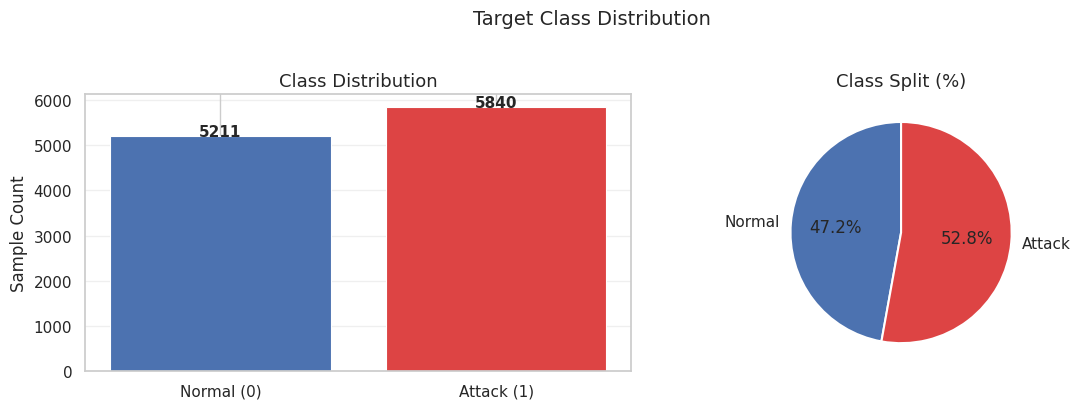

Total samples : 11,051
Normal (0)    : 5,211  (47.2%)
Attack (1)    : 5,840  (52.8%)


In [ ]:

# EDA-1  Class Distribution
# Re-load the raw data (before noise) for clean EDA visualisation
df_raw = pd.read_csv("ids_dataset_ready_for_ml.csv").dropna()
for c in ['proto_other', 'syn_ack_ratio', 'window_size_mean']:
    if c in df_raw.columns: df_raw.drop(columns=c, inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count-plot
counts = df_raw['Label'].value_counts()
axes[0].bar(['Normal (0)', 'Attack (1)'], [counts.get(0,0), counts.get(1,0)],
            color=['#4C72B0', '#DD4444'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_ylabel('Sample Count')
for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=11, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie([counts.get(0,0), counts.get(1,0)],
            labels=['Normal', 'Attack'],
            colors=['#4C72B0', '#DD4444'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Class Split (%)', fontsize=13)

plt.suptitle('Target Class Distribution', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print(f"Total samples : {len(df_raw):,}")
print(f"Normal (0)    : {counts.get(0,0):,}  ({counts.get(0,0)/len(df_raw)*100:.1f}%)")
print(f"Attack (1)    : {counts.get(1,0):,}  ({counts.get(1,0)/len(df_raw)*100:.1f}%)")


In [ ]:

# EDA-2  Missing Values Check
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) == 0:
    print("  No missing values found in the dataset.")
    print(f" Dataset is clean: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
else:
    print("  Missing values detected:")
    print(missing_df.to_string())

print(f"\nDataset dtypes:")
print(df_raw.dtypes.value_counts().to_string())
print(f"\nBasic statistics:")
print(df_raw.describe().round(3).to_string())


  No missing values found in the dataset.
 Dataset is clean: 11,051 rows × 23 columns

Dataset dtypes:
float64    19
int64       4

Basic statistics:
       total_packets  total_bytes  flow_duration_sec  bytes_per_sec  pkts_per_sec  pkt_len_mean  pkt_len_std  pkt_len_min  pkt_len_max   iat_mean    iat_std    iat_min    iat_max  syn_count  ack_count  fin_count  rst_count   ttl_mean  retransmission_count  proto_tcp  proto_udp  proto_icmp      Label
count      11051.000    11051.000          11051.000      11051.000     11051.000     11051.000    11051.000    11051.000    11051.000  11051.000  11051.000  11051.000  11051.000  11051.000  11051.000  11051.000  11051.000  11051.000             11051.000  11051.000  11051.000   11051.000  11051.000
mean           0.254        0.199              0.338         -0.133         0.009         0.812        0.524        0.535        0.892      0.319      0.350      0.902      0.355      0.156      0.284      0.160      0.118      0.212               

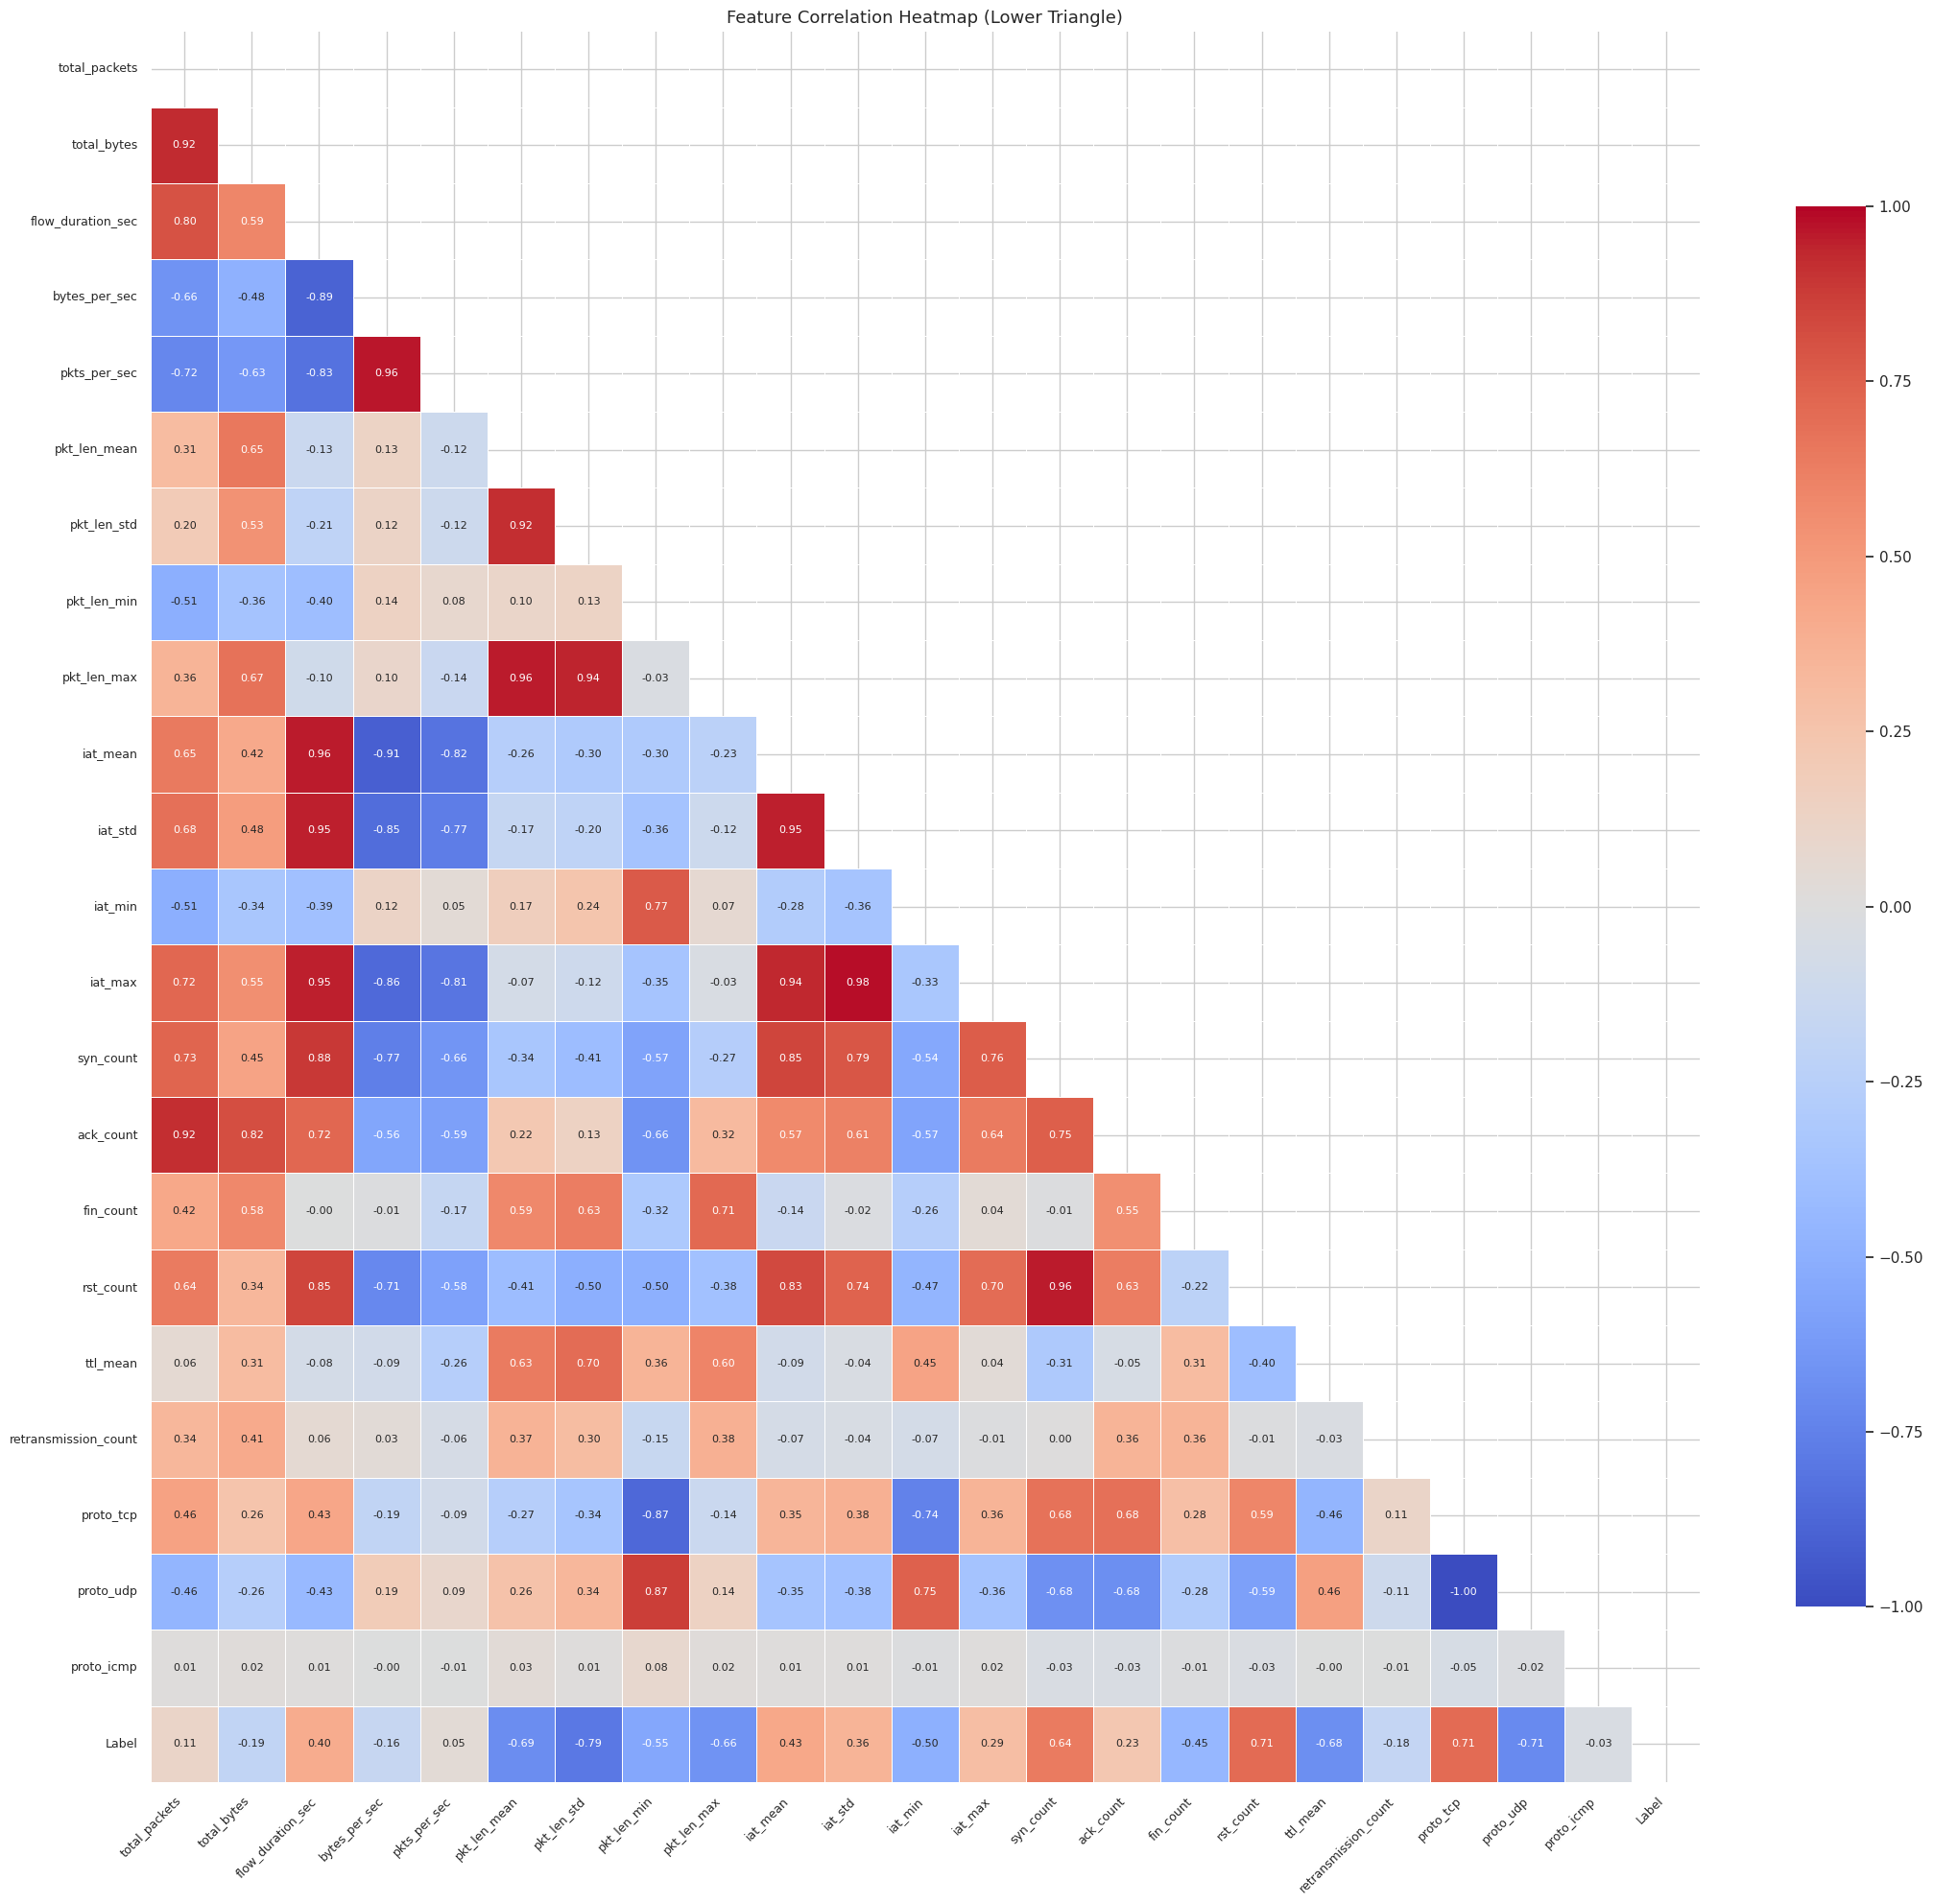


Top features correlated with Label (|r|):
pkt_len_std     0.794760
proto_tcp       0.710537
rst_count       0.709832
proto_udp       0.708584
pkt_len_mean    0.688860
ttl_mean        0.683907
pkt_len_max     0.662950
syn_count       0.637933
pkt_len_min     0.554670
iat_min         0.499616


In [ ]:
# EDA-3  Correlation Heatmap
feat_cols_raw = [c for c in df_raw.columns if c != 'Label']
corr_matrix = df_raw[feat_cols_raw + ['Label']].corr()

plt.figure(figsize=(max(10, len(feat_cols_raw)), max(8, len(feat_cols_raw)-2)))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 8})
plt.title('Feature Correlation Heatmap (Lower Triangle)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(); plt.show()

# Highlight features most correlated with the label
label_corr = corr_matrix['Label'].drop('Label').abs().sort_values(ascending=False)
print("\nTop features correlated with Label (|r|):")
print(label_corr.head(10).to_string())


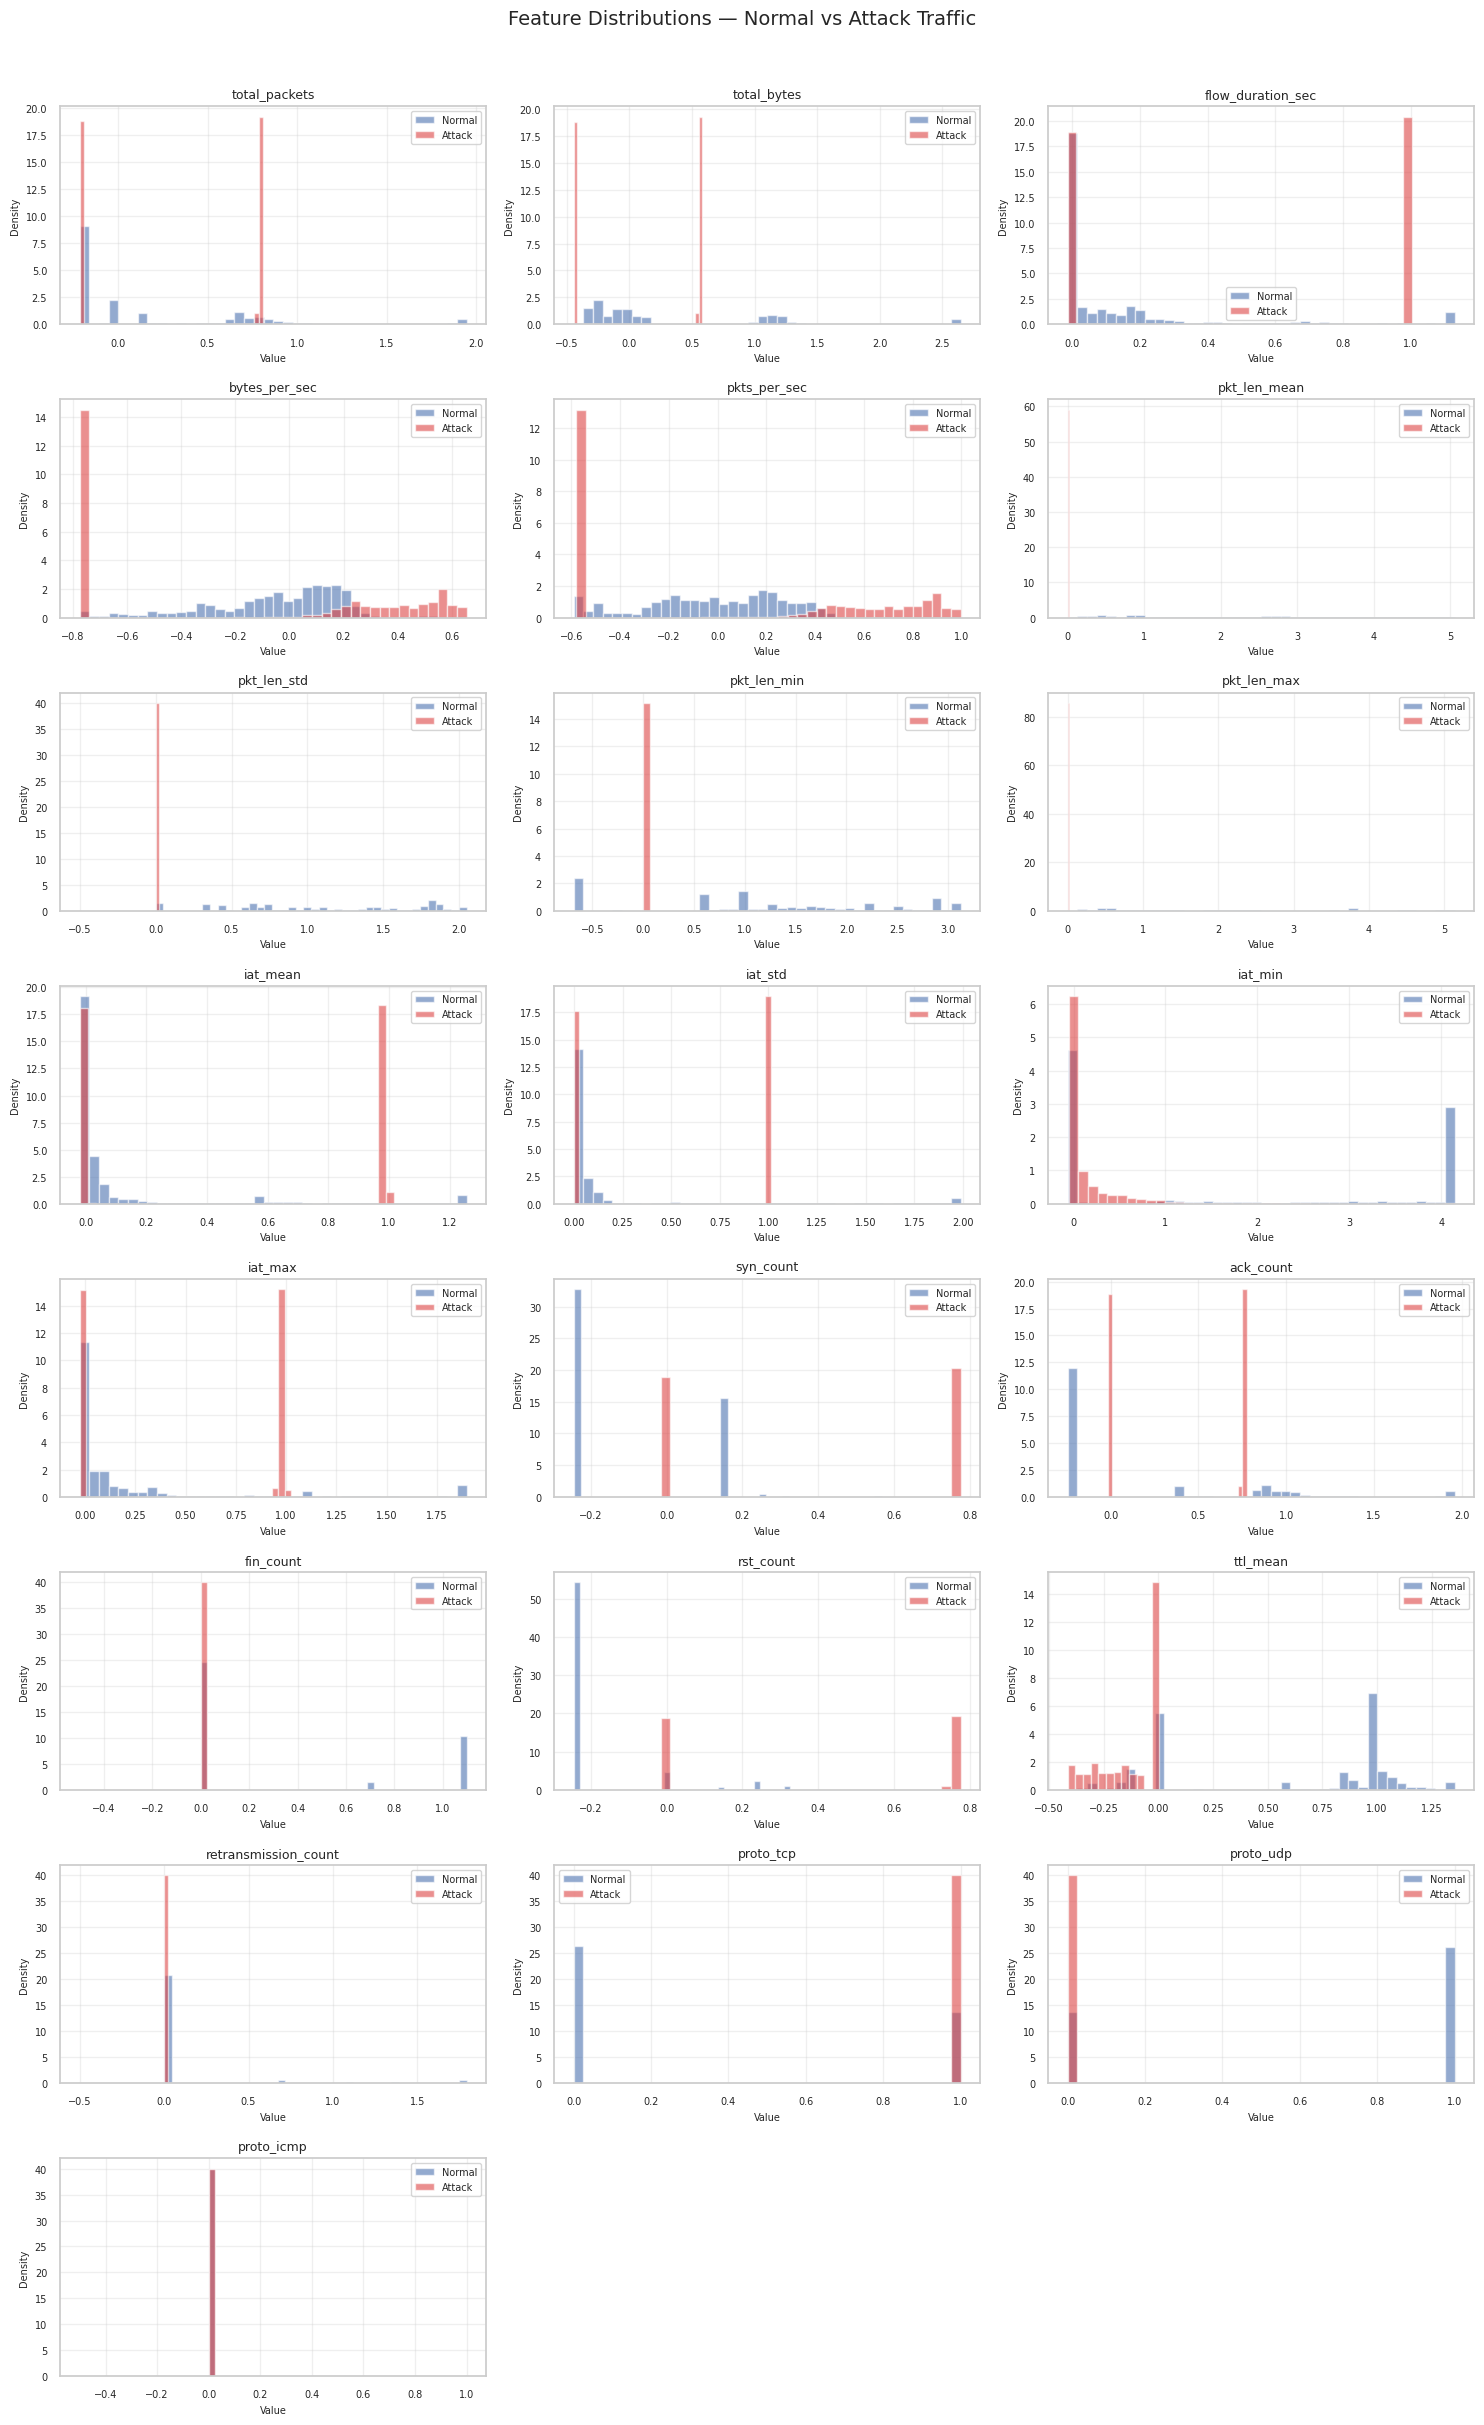

In [ ]:
# EDA-4  Feature Histograms (Normal vs Attack overlay)
normal_df = df_raw[df_raw['Label'] == 0]
attack_df = df_raw[df_raw['Label'] == 1]

n_features = len(feat_cols_raw)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(feat_cols_raw):
    ax = axes[i]
    ax.hist(normal_df[feat].dropna(), bins=40, alpha=0.6, color='#4C72B0',
            label='Normal', density=True)
    ax.hist(attack_df[feat].dropna(), bins=40, alpha=0.6, color='#DD4444',
            label='Attack', density=True)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('Value', fontsize=7)
    ax.set_ylabel('Density', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions — Normal vs Attack Traffic', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


---
## 2. Algorithm Implementations


### Why Logistic Regression for IDS?

Logistic Regression is a strong baseline for intrusion detection because:

- **Interpretability**: Each feature coefficient directly shows its contribution to the attack/normal decision, making it easy to explain predictions during a security audit or viva.
- **Efficiency**: LR trains in seconds even on large flow datasets — critical for real-time IDS deployment.
- **Regularisation**: L1 (LASSO) forces sparse weights, performing automatic feature selection and suppressing noisy network features. L2 (Ridge) and ElasticNet provide additional bias-variance control.
- **Probabilistic output**: The sigmoid output gives a confidence score for each prediction, enabling threshold tuning to balance FPR/FNR according to the network's risk tolerance.

Three variants are tested — L1, L2, and ElasticNet — to compare regularisation strategies under the same split conditions.

### 2A · Logistic Regression
Models log-odds linearly: $P(y=1|\mathbf x)=\sigma(\mathbf w^\top\mathbf x+b)$

| Variant | Penalty | C | Solver | Effect |
|---|---|---|---|---|
| **LR-L1** | L1 (LASSO) | 0.1 | liblinear | Sparse weights → automatic feature selection |
| **LR-L2** | L2 (Ridge) | 0.1 | lbfgs | Shrinks all weights uniformly |
| **LR-EN** | ElasticNet | 0.05 | saga | Combines L1+L2; `l1_ratio=0.6` |

*Smaller C = stronger regularisation. All use `class_weight='balanced'`.*

In [ ]:
LR_DEFS = {
    "LR-L1": dict(C=0.1,  penalty='l1', solver='liblinear', l1_ratio=None),
    "LR-L2": dict(C=0.1,  penalty='l2', solver='lbfgs',     l1_ratio=None),
    "LR-EN": dict(C=0.05, penalty='elasticnet', solver='saga', l1_ratio=0.6),
}

def make_lr(key):
    p = LR_DEFS[key]
    kw = dict(C=p['C'], penalty=p['penalty'], solver=p['solver'],
              class_weight='balanced', max_iter=5000, random_state=SEED)
    if p['l1_ratio'] is not None: kw['l1_ratio'] = p['l1_ratio']
    return LogisticRegression(**kw)

print("LR variants ready:", list(LR_DEFS))


LR variants ready: ['LR-L1', 'LR-L2', 'LR-EN']


### Why Decision Trees for IDS?

Decision Trees are particularly suited to network intrusion detection because:

- **Rule extraction**: Each path from root to leaf translates directly into a human-readable detection rule (e.g., *"IF packet_rate > 500 AND protocol = UDP → ATTACK"*). This matters for SOC analysts who need to understand and audit decisions.
- **Non-linearity**: DTs capture complex, non-linear decision boundaries without feature scaling — useful since network flow features span very different value ranges.
- **Feature importance**: Node split frequencies give a built-in feature ranking with no extra computation.
- **Speed**: Inference is O(log n) — ideal for high-throughput packet inspection.

Three depth variants are tested: Shallow (depth=3) for maximum interpretability, Balanced (depth=7) for a bias-variance tradeoff, and Deep (unconstrained) to reveal overfitting risk.

### 2B · Decision Tree
Recursively partitions by maximising Gini or Entropy reduction.

$$\text{Gini}(t)=1-\sum_k p_k^2 \qquad \text{Entropy}(t)=-\sum_k p_k\log_2 p_k$$

| Variant | Depth | Criterion | Character |
|---|---|---|---|
| **DT-Shallow** | 3 | Gini | Underfits — maximally interpretable |
| **DT-Balanced** | 7 | Entropy | Bias-variance sweet spot |
| **DT-Deep** | None | Gini | Full tree — risk of overfit |

In [ ]:
DT_DEFS = {
    "DT-Shallow":  dict(max_depth=3,    criterion='gini',    min_samples_split=2, random_state=SEED),
    "DT-Balanced": dict(max_depth=7,    criterion='entropy', min_samples_split=5, random_state=SEED),
    "DT-Deep":     dict(max_depth=None, criterion='gini',    min_samples_split=2, random_state=SEED),
}
print("DT variants ready:", list(DT_DEFS))


DT variants ready: ['DT-Shallow', 'DT-Balanced', 'DT-Deep']


### Why Neural Networks for IDS?

Neural Networks are the most powerful option in this project for several reasons:

- **Automatic feature learning**: Hidden layers learn latent representations of traffic patterns that hand-crafted features may miss — critical for detecting novel or obfuscated attacks.
- **High-dimensional handling**: NNs naturally handle the many correlated, noisy features present in network flow data.
- **Non-linear decision boundaries**: Multi-layer architectures can model arbitrarily complex traffic signatures without explicit feature engineering.
- **Regularisation variety**: Dropout + L1/L2 weight penalties provide powerful overfitting control — essential given the noise injected into this dataset to simulate real-world sensor uncertainty.
- **Adaptability**: Architectures can be scaled (more layers, more units) as traffic volume or attack diversity grows.

Three architectures are compared: Conservative (small, heavily regularised), Balanced (moderate), and Aggressive (larger capacity, lighter regularisation). Both 70/15/15 and 80/10/10 splits are used to assess sensitivity to training data volume.

### 2C · Neural Network
Binary cross-entropy loss, Adam optimiser, early stopping on `val_loss`.

$$\hat y=\sigma\!\left(W_L\cdot\text{ReLU}(\cdots)\cdots+b_L\right)$$

| Variant | Architecture | Regularisation | Character |
|---|---|---|---|
| **NN-Conservative** | 16→8→1 | L2 1e-2, Dropout 0.6/0.5 | Small, heavily regularised |
| **NN-Balanced** | 32→16→1 | L2 1e-3, Dropout 0.5/0.4 | Moderate capacity |
| **NN-Aggressive** | 64→32→16→1 | L1 1e-4, Dropout 0.3/0.2 | Larger, lighter reg |

In [ ]:
def _nn_conservative(d):
    return Sequential([Input((d,)),
        Dense(16,'relu',kernel_regularizer=l2(1e-2)), Dropout(0.6),
        Dense(8, 'relu',kernel_regularizer=l2(1e-2)), Dropout(0.5),
        Dense(1,'sigmoid')])

def _nn_balanced(d):
    return Sequential([Input((d,)),
        Dense(32,'relu',kernel_regularizer=l2(1e-3)), Dropout(0.5),
        Dense(16,'relu',kernel_regularizer=l2(1e-3)), Dropout(0.4),
        Dense(1,'sigmoid')])

def _nn_aggressive(d):
    return Sequential([Input((d,)),
        Dense(64,'relu',kernel_regularizer=l1(1e-4)), Dropout(0.3),
        Dense(32,'relu',kernel_regularizer=l1(1e-4)), Dropout(0.2),
        Dense(16,'relu'),
        Dense(1,'sigmoid')])

NN_DEFS = {
    "NN-Conservative": dict(builder=_nn_conservative, epochs=80,  patience=6),
    "NN-Balanced":     dict(builder=_nn_balanced,     epochs=100, patience=8),
    "NN-Aggressive":   dict(builder=_nn_aggressive,   epochs=120, patience=10),
}

def train_nn(cfg, Xtr, ytr, Xv, yv):
    m = cfg['builder'](Xtr.shape[1])
    m.compile('adam','binary_crossentropy',metrics=['accuracy'])
    es = EarlyStopping('val_loss', patience=cfg['patience'], restore_best_weights=True, verbose=0)
    h  = m.fit(Xtr, ytr, validation_data=(Xv,yv),
               epochs=cfg['epochs'], batch_size=32, callbacks=[es], verbose=0)
    return m, h

print("NN builders ready:", list(NN_DEFS))


NN builders ready: ['NN-Conservative', 'NN-Balanced', 'NN-Aggressive']


---
## 3. Model Training & Evaluation

### Why F1 and ROC-AUC are the key metrics for IDS

In an Intrusion Detection System, the classes are often **imbalanced** (fewer attacks than normal traffic in production) and the **costs of errors are asymmetric**:

- A **False Negative** (missed attack) is a security breach — potentially catastrophic.
- A **False Positive** (flagging normal traffic) causes alert fatigue and operational overhead.

**F1-score** balances Precision and Recall into a single number, penalising both types of error equally. It is the standard metric when class distribution is uneven or when both FP and FN carry significant cost.

**ROC-AUC** measures the model's ability to discriminate between classes across *all* decision thresholds, not just the default 0.5. A higher AUC means the model can be tuned to a tighter FPR/FNR operating point — essential for adapting to different network environments.

Together, F1 and ROC-AUC give a complete picture of model quality for IDS.

### 3A · Logistic Regression — Train (Both Splits)

In [ ]:
for split_lbl, (Xtr,Xv,Xte,ytr,yv,yte,_) in SPLITS.items():
    for name in LR_DEFS:
        t0  = time.time()
        m   = make_lr(name)
        m.fit(Xtr, ytr)
        elapsed = time.time() - t0
        res = metrics_sklearn(m, Xtr,ytr, Xv,yv, Xte,yte)
        key = f"{name} [{split_lbl}]"
        ALL_RESULTS[key]  = dict(Split=split_lbl, Category="Logistic Regression",
                                 model=m, **res)
        TRAIN_TIMES[key]  = round(elapsed, 3)
        print_metrics(key, res)

print("\n  LR training complete —", len([k for k in ALL_RESULTS if 'LR' in k]), "models stored.")



──────────────────────────────────────────────────────────────
  LR-L1 [70/15/15]
──────────────────────────────────────────────────────────────
       Accuracy  Precision  Recall      F1  ROC_AUC
Train    0.8880     0.8705  0.9234  0.8962   0.9300
Val      0.8987     0.8780  0.9366  0.9064   0.9326
Test     0.8739     0.8673  0.8963  0.8816   0.9198
  Train-Val F1 gap: -0.0102  ✓ Good

──────────────────────────────────────────────────────────────
  LR-L2 [70/15/15]
──────────────────────────────────────────────────────────────
       Accuracy  Precision  Recall      F1  ROC_AUC
Train    0.8887     0.8717  0.9232  0.8967   0.9301
Val      0.8987     0.8788  0.9355  0.9062   0.9327
Test     0.8752     0.8701  0.8952  0.8825   0.9197
  Train-Val F1 gap: -0.0095  ✓ Good

──────────────────────────────────────────────────────────────
  LR-EN [70/15/15]
──────────────────────────────────────────────────────────────
       Accuracy  Precision  Recall      F1  ROC_AUC
Train    0.8880     0.

#### LR · Feature Coefficient Plot (L1, 70/15/15)

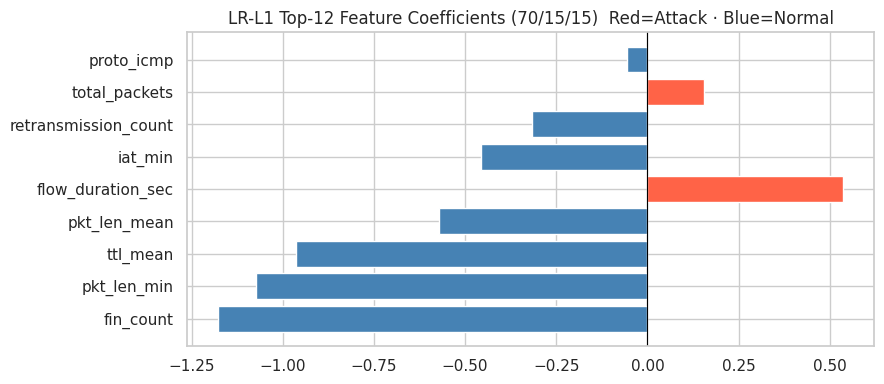

In [ ]:
lr_obj = ALL_RESULTS["LR-L1 [70/15/15]"]["model"]
coef_s = pd.Series(lr_obj.coef_[0], index=FEAT_COLS).reindex(
             pd.Series(lr_obj.coef_[0], index=FEAT_COLS).abs().sort_values(ascending=False).index)[:12]

colors = ["tomato" if v > 0 else "steelblue" for v in coef_s]
plt.figure(figsize=(9,4))
plt.barh(coef_s.index, coef_s.values, color=colors)
plt.axvline(0, color='k', lw=0.8)
plt.title("LR-L1 Top-12 Feature Coefficients (70/15/15)  Red=Attack · Blue=Normal")
plt.tight_layout(); plt.show()


#### LR · Feature Importance Commentary

The coefficient plot above reveals which network features drive the Logistic Regression decision most strongly:

- **Large positive coefficients (red bars)** indicate features that push the model toward predicting *Attack*. Features related to packet rate, byte counts per flow, or flag counts typically dominate here — these spike during flood or scan attacks.
- **Large negative coefficients (blue bars)** push toward *Normal* traffic. Features reflecting stable, low-volume connections (e.g., typical window sizes or inter-arrival times) tend to carry negative weights.
- **Near-zero coefficients** (suppressed by L1 regularisation) confirm that those features carry little discriminative signal and can safely be dropped in a leaner production model.

This plot is a direct interpretability advantage of Logistic Regression: each bar is an auditable reason why the model flags traffic as malicious.

#### LR · 5-Fold Cross-Validation Stability

In [ ]:
cv  = StratifiedKFold(5, shuffle=True, random_state=SEED)
Xsc = StandardScaler().fit_transform(X_all)

print(f"{'Model':<14}  {'CV F1':>8}  {'CV F1 σ':>8}  {'CV AUC':>8}")
print("─"*46)
for name in LR_DEFS:
    m   = make_lr(name)
    f1s = cross_val_score(m, Xsc, y_all, cv=cv, scoring='f1')
    aus = cross_val_score(m, Xsc, y_all, cv=cv, scoring='roc_auc')
    print(f"{name:<14}  {f1s.mean():>8.4f}  {f1s.std():>8.4f}  {aus.mean():>8.4f}")


Model              CV F1   CV F1 σ    CV AUC
──────────────────────────────────────────────
LR-L1             0.8957    0.0069    0.9288
LR-L2             0.8957    0.0068    0.9288
LR-EN             0.8955    0.0071    0.9287


#### LR · Confusion Matrix — Best LR Model (LR-L1, 70/15/15)

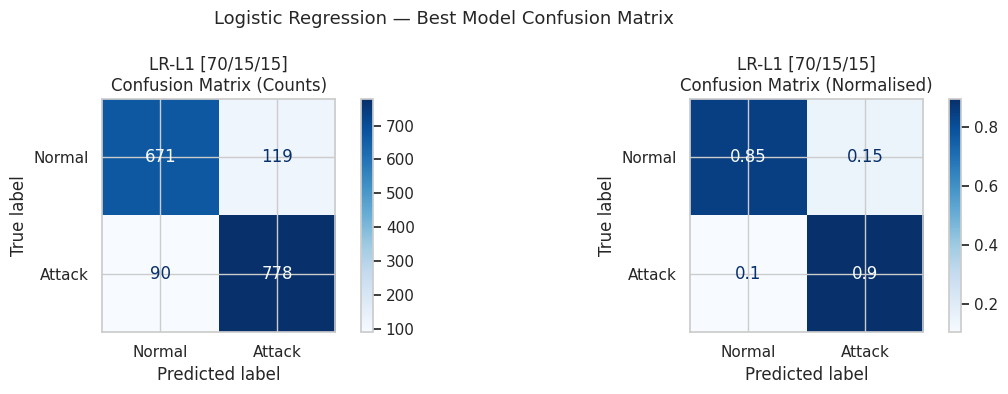


Classification Report — LR-L1 [70/15/15]
              precision    recall  f1-score   support

      Normal       0.88      0.85      0.87       790
      Attack       0.87      0.90      0.88       868

    accuracy                           0.87      1658
   macro avg       0.87      0.87      0.87      1658
weighted avg       0.87      0.87      0.87      1658



In [ ]:
best_lr_key = "LR-L1 [70/15/15]"
best_lr     = ALL_RESULTS[best_lr_key]["model"]
y_pred_lr   = best_lr.predict(Xte70)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw counts
ConfusionMatrixDisplay.from_predictions(
    yte70, y_pred_lr,
    display_labels=["Normal", "Attack"],
    cmap="Blues", ax=axes[0])
axes[0].set_title(f"{best_lr_key}\nConfusion Matrix (Counts)")

# Normalised
ConfusionMatrixDisplay.from_predictions(
    yte70, y_pred_lr,
    display_labels=["Normal", "Attack"],
    normalize="true", cmap="Blues", ax=axes[1])
axes[1].set_title(f"{best_lr_key}\nConfusion Matrix (Normalised)")

plt.suptitle("Logistic Regression — Best Model Confusion Matrix", fontsize=13)
plt.tight_layout(); plt.show()

print(f"\nClassification Report — {best_lr_key}")
print(classification_report(yte70, y_pred_lr, target_names=["Normal","Attack"]))


#### LR · ROC Curve & Precision-Recall Curve (Best LR)

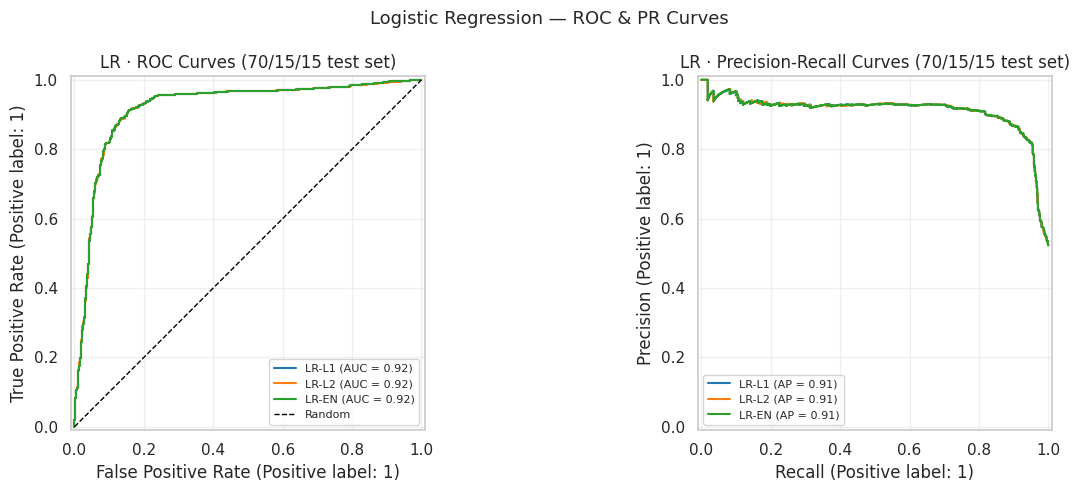

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curves for all LR variants on test set
for name in LR_DEFS:
    key = f"{name} [70/15/15]"
    m   = ALL_RESULTS[key]["model"]
    RocCurveDisplay.from_predictions(
        yte70, m.predict_proba(Xte70)[:,1],
        name=name, ax=axes[0])
axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random')
axes[0].set_title("LR · ROC Curves (70/15/15 test set)")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Precision-Recall curves
for name in LR_DEFS:
    key = f"{name} [70/15/15]"
    m   = ALL_RESULTS[key]["model"]
    PrecisionRecallDisplay.from_predictions(
        yte70, m.predict_proba(Xte70)[:,1],
        name=name, ax=axes[1])
axes[1].set_title("LR · Precision-Recall Curves (70/15/15 test set)")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.suptitle("Logistic Regression — ROC & PR Curves", fontsize=13)
plt.tight_layout(); plt.show()


### 3B · Decision Tree — Train (Both Splits)

In [ ]:
DT_MODELS = {}

for split_lbl, (Xtr,Xv,Xte,ytr,yv,yte,_) in SPLITS.items():
    for name, params in DT_DEFS.items():
        t0 = time.time()
        m  = DecisionTreeClassifier(**params)
        m.fit(Xtr, ytr)
        elapsed = time.time() - t0
        res = metrics_sklearn(m, Xtr,ytr, Xv,yv, Xte,yte)
        key = f"{name} [{split_lbl}]"
        ALL_RESULTS[key] = dict(Split=split_lbl, Category="Decision Tree", model=m, **res)
        DT_MODELS[key]   = m
        TRAIN_TIMES[key] = round(elapsed, 3)
        print_metrics(key, res)

print("\n  DT training complete —", len([k for k in ALL_RESULTS if 'DT' in k]), "models stored.")



──────────────────────────────────────────────────────────────
  DT-Shallow [70/15/15]
──────────────────────────────────────────────────────────────
       Accuracy  Precision  Recall      F1  ROC_AUC
Train    0.8816     0.8553  0.9313  0.8917   0.8910
Val      0.8800     0.8510  0.9343  0.8907   0.8899
Test     0.8607     0.8496  0.8917  0.8702   0.8801
  Train-Val F1 gap: +0.0010  ✓ Good

──────────────────────────────────────────────────────────────
  DT-Balanced [70/15/15]
──────────────────────────────────────────────────────────────
       Accuracy  Precision  Recall      F1  ROC_AUC
Train    0.9037     0.8732  0.9545  0.9121   0.9512
Val      0.8818     0.8457  0.9470  0.8935   0.9140
Test     0.8745     0.8548  0.9159  0.8843   0.9042
  Train-Val F1 gap: +0.0186  ✓ Good

──────────────────────────────────────────────────────────────
  DT-Deep [70/15/15]
──────────────────────────────────────────────────────────────
       Accuracy  Precision  Recall      F1  ROC_AUC
Train    

#### DT · Tree Visualisation (Shallow, 70/15/15)

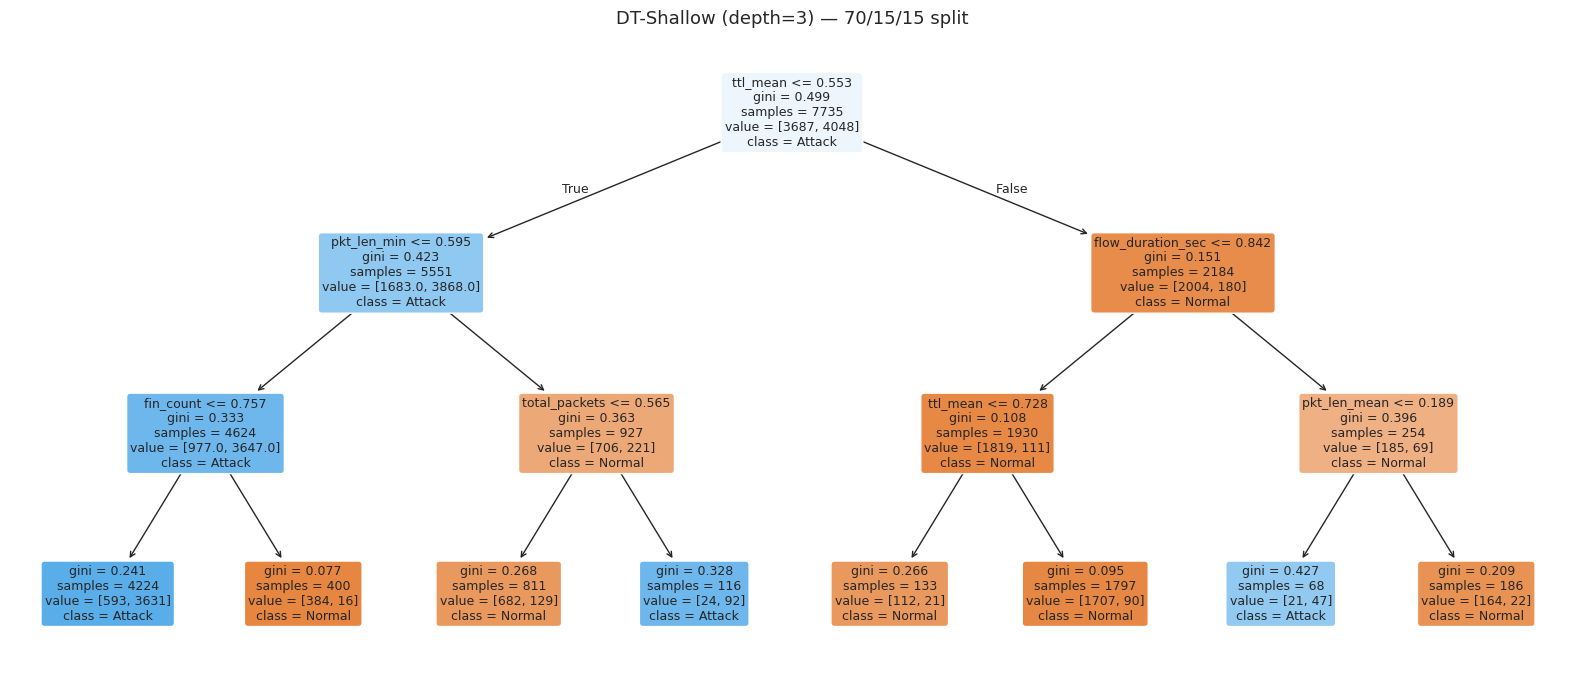

In [ ]:
plt.figure(figsize=(16,7))
plot_tree(DT_MODELS["DT-Shallow [70/15/15]"],
          feature_names=FEAT_COLS, class_names=["Normal","Attack"],
          filled=True, rounded=True, fontsize=9)
plt.title("DT-Shallow (depth=3) — 70/15/15 split", fontsize=13)
plt.tight_layout(); plt.show()


#### DT · Learning Curves (70/15/15)

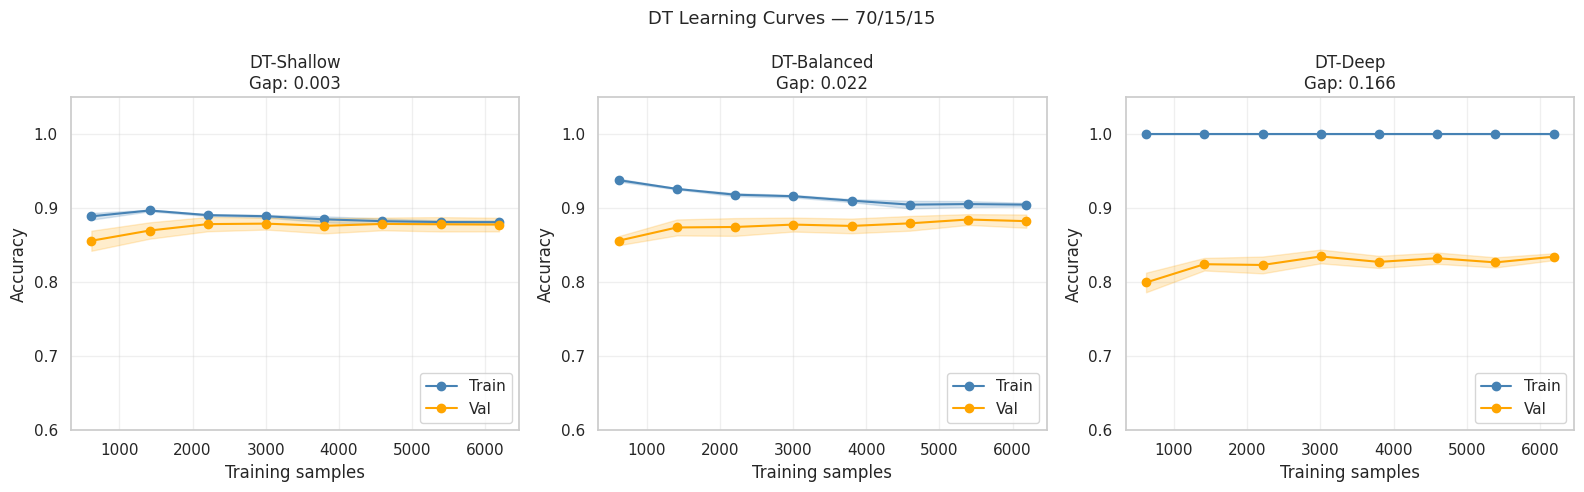

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

for ax, (name, params) in zip(axes, DT_DEFS.items()):
    szs, tr_sc, val_sc = learning_curve(
        DecisionTreeClassifier(**params), Xtr70, ytr70,
        cv=5, train_sizes=np.linspace(0.1,1.0,8), scoring='accuracy', n_jobs=-1, random_state=SEED)
    ax.plot(szs, tr_sc.mean(1),  'o-', color='steelblue', label='Train')
    ax.fill_between(szs, tr_sc.mean(1)-tr_sc.std(1), tr_sc.mean(1)+tr_sc.std(1), alpha=.2, color='steelblue')
    ax.plot(szs, val_sc.mean(1), 'o-', color='orange',    label='Val')
    ax.fill_between(szs, val_sc.mean(1)-val_sc.std(1), val_sc.mean(1)+val_sc.std(1), alpha=.2, color='orange')
    ax.set_title(f"{name}\nGap: {tr_sc.mean(1)[-1]-val_sc.mean(1)[-1]:.3f}")
    ax.set_xlabel("Training samples"); ax.set_ylabel("Accuracy")
    ax.legend(loc='lower right'); ax.grid(alpha=0.3); ax.set_ylim(0.6,1.05)

plt.suptitle("DT Learning Curves — 70/15/15", fontsize=13)
plt.tight_layout(); plt.show()


#### DT · Split Ratio Effect (DT-Balanced)

In [ ]:
rows = []
for split_lbl, (Xtr,Xv,Xte,ytr,yv,yte,_) in SPLITS.items():
    m = DecisionTreeClassifier(**DT_DEFS["DT-Balanced"]); m.fit(Xtr, ytr)
    rows.append({"Split":split_lbl,"Train":len(Xtr),"Val":len(Xv),"Test":len(Xte),
                 "Train Acc":round(accuracy_score(ytr,m.predict(Xtr)),4),
                 "Val Acc":  round(accuracy_score(yv, m.predict(Xv)),4),
                 "Test Acc": round(accuracy_score(yte,m.predict(Xte)),4),
                 "Test F1":  round(f1_score(yte,m.predict(Xte)),4)})
print(pd.DataFrame(rows).to_string(index=False))


   Split  Train  Val  Test  Train Acc  Val Acc  Test Acc  Test F1
70/15/15   7735 1658  1658     0.9037   0.8818    0.8745   0.8843
80/10/10   8840 1105  1106     0.9034   0.8851    0.8734   0.8839


#### DT · Confusion Matrix — Best DT Model (DT-Balanced, 70/15/15)

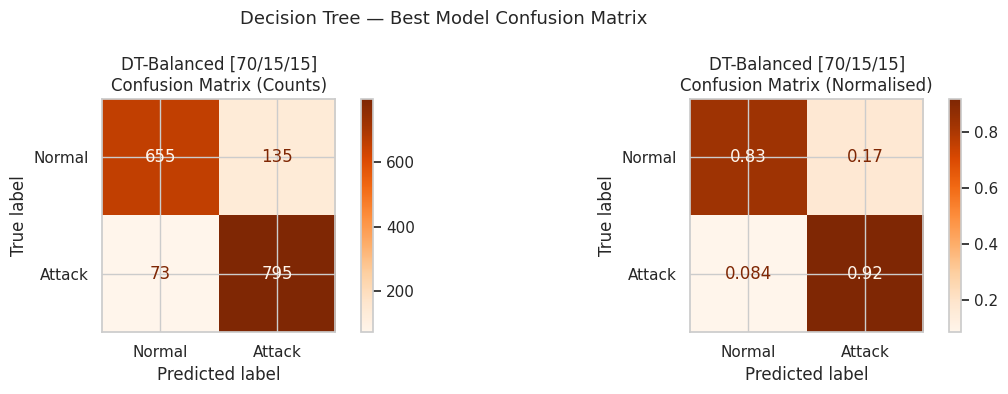


Classification Report — DT-Balanced [70/15/15]
              precision    recall  f1-score   support

      Normal       0.90      0.83      0.86       790
      Attack       0.85      0.92      0.88       868

    accuracy                           0.87      1658
   macro avg       0.88      0.87      0.87      1658
weighted avg       0.88      0.87      0.87      1658



In [ ]:
best_dt_key = "DT-Balanced [70/15/15]"
best_dt     = ALL_RESULTS[best_dt_key]["model"]
y_pred_dt   = best_dt.predict(Xte70)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    yte70, y_pred_dt,
    display_labels=["Normal", "Attack"],
    cmap="Oranges", ax=axes[0])
axes[0].set_title(f"{best_dt_key}\nConfusion Matrix (Counts)")

ConfusionMatrixDisplay.from_predictions(
    yte70, y_pred_dt,
    display_labels=["Normal", "Attack"],
    normalize="true", cmap="Oranges", ax=axes[1])
axes[1].set_title(f"{best_dt_key}\nConfusion Matrix (Normalised)")

plt.suptitle("Decision Tree — Best Model Confusion Matrix", fontsize=13)
plt.tight_layout(); plt.show()

print(f"\nClassification Report — {best_dt_key}")
print(classification_report(yte70, y_pred_dt, target_names=["Normal","Attack"]))


#### DT · ROC Curve & Precision-Recall Curve (All DT Variants)

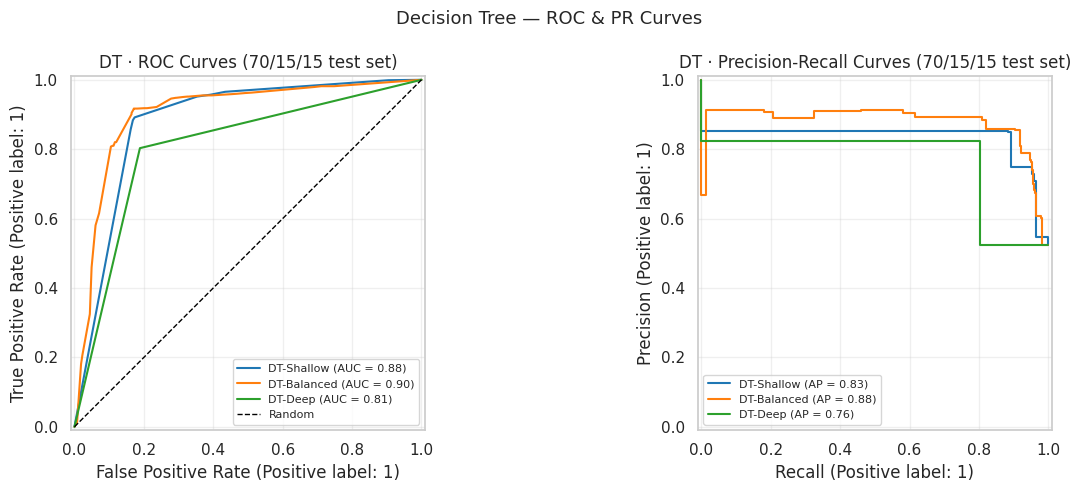

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name in DT_DEFS:
    key = f"{name} [70/15/15]"
    m   = ALL_RESULTS[key]["model"]
    RocCurveDisplay.from_predictions(
        yte70, m.predict_proba(Xte70)[:,1],
        name=name, ax=axes[0])
axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random')
axes[0].set_title("DT · ROC Curves (70/15/15 test set)")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

for name in DT_DEFS:
    key = f"{name} [70/15/15]"
    m   = ALL_RESULTS[key]["model"]
    PrecisionRecallDisplay.from_predictions(
        yte70, m.predict_proba(Xte70)[:,1],
        name=name, ax=axes[1])
axes[1].set_title("DT · Precision-Recall Curves (70/15/15 test set)")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.suptitle("Decision Tree — ROC & PR Curves", fontsize=13)
plt.tight_layout(); plt.show()


### 3C · Neural Network — Train (Both Splits)

In [ ]:
NN_MODELS    = {}
NN_HISTORIES = {}

for split_lbl, (Xtr,Xv,Xte,ytr,yv,yte,_) in SPLITS.items():
    print(f"\n{'═'*52}\n  Training NNs on {split_lbl}\n{'═'*52}")
    for name, cfg in NN_DEFS.items():
        print(f"  → {name} ...", end=" ", flush=True)
        t0   = time.time()
        m, h = train_nn(cfg, Xtr, ytr, Xv, yv)
        elapsed = time.time() - t0
        res  = metrics_nn(m, Xtr,ytr, Xv,yv, Xte,yte)
        key  = f"{name} [{split_lbl}]"
        ALL_RESULTS[key]  = dict(Split=split_lbl, Category="Neural Network", model=m, **res)
        NN_MODELS[key]    = m
        NN_HISTORIES[key] = h
        TRAIN_TIMES[key]  = round(elapsed, 1)
        print(f"done  (Test F1={res['Test']['F1']})")
        print_metrics(key, res)

print("\n  NN training complete —", len([k for k in ALL_RESULTS if 'NN' in k]), "models stored.")
print(f"\n ALL_RESULTS now contains {len(ALL_RESULTS)} models.")



════════════════════════════════════════════════════
  Training NNs on 70/15/15
════════════════════════════════════════════════════
  → NN-Conservative ... done  (Test F1=0.8824)

──────────────────────────────────────────────────────────────
  NN-Conservative [70/15/15]
──────────────────────────────────────────────────────────────
       Accuracy  Precision  Recall      F1  ROC_AUC
Train    0.8897     0.8774  0.9175  0.8970   0.9315
Val      0.8993     0.8822  0.9320  0.9064   0.9338
Test     0.8758     0.8744  0.8906  0.8824   0.9218
  Train-Val F1 gap: -0.0094  ✓ Good
  → NN-Balanced ... done  (Test F1=0.8955)

──────────────────────────────────────────────────────────────
  NN-Balanced [70/15/15]
──────────────────────────────────────────────────────────────
       Accuracy  Precision  Recall      F1  ROC_AUC
Train    0.9017     0.8863  0.9318  0.9085   0.9389
Val      0.9107     0.8939  0.9412  0.9169   0.9397
Test     0.8896     0.8879  0.9032  0.8955   0.9277
  Train-Val F1 g

#### NN · Training Curves (70/15/15)

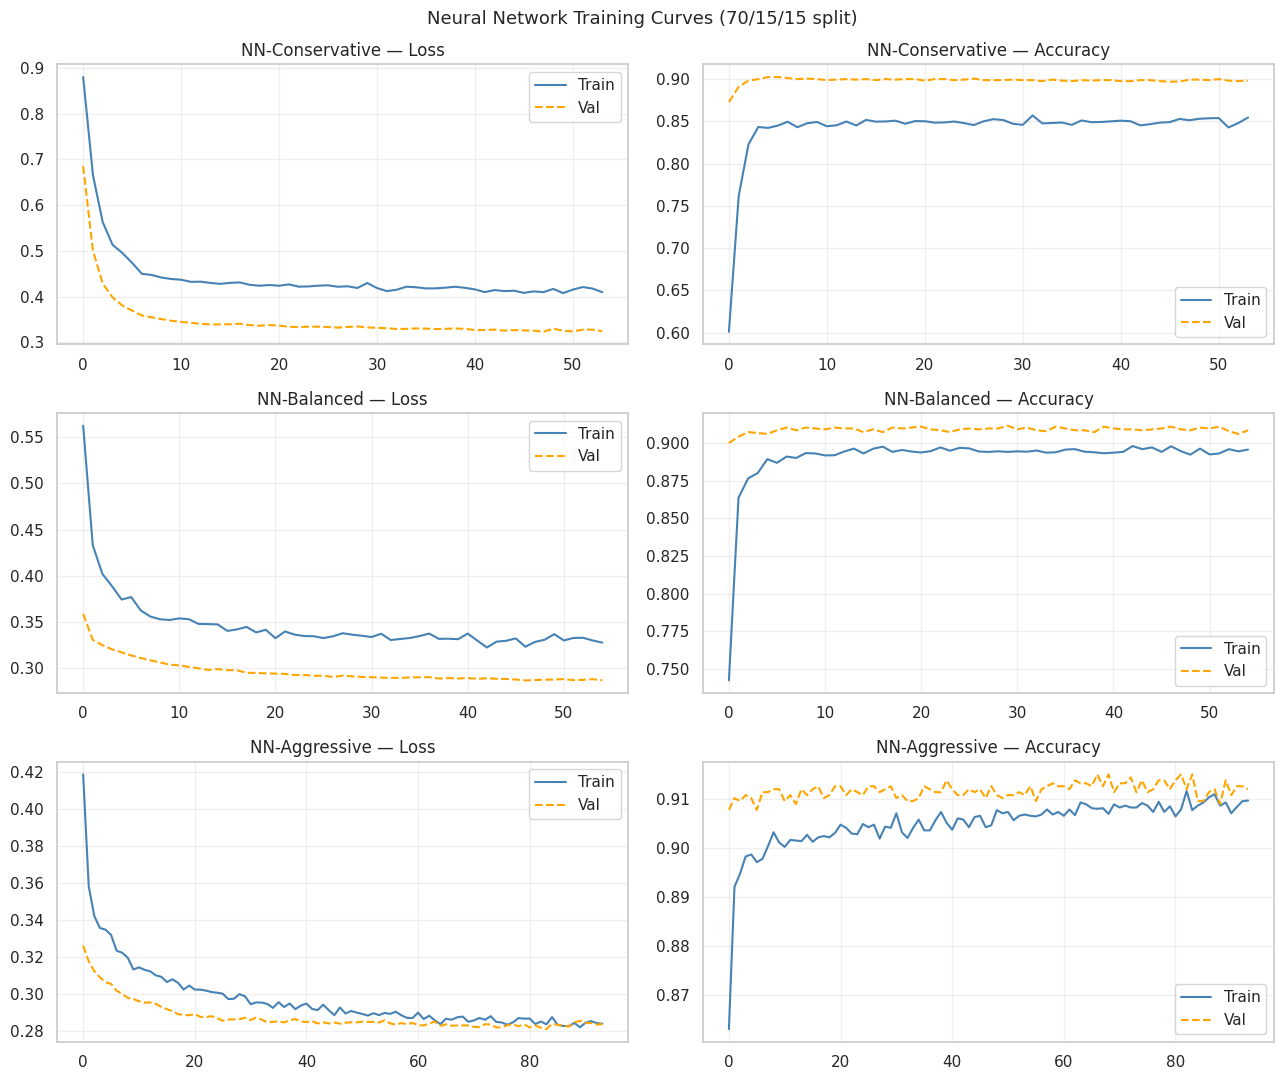

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(13,11))

for row, name in enumerate(NN_DEFS):
    hist = NN_HISTORIES[f"{name} [70/15/15]"].history
    axes[row,0].plot(hist['loss'],         label='Train', color='steelblue')
    axes[row,0].plot(hist['val_loss'],     label='Val',   color='orange', ls='--')
    axes[row,0].set_title(f"{name} — Loss"); axes[row,0].legend(); axes[row,0].grid(alpha=0.3)

    axes[row,1].plot(hist['accuracy'],     label='Train', color='steelblue')
    axes[row,1].plot(hist['val_accuracy'], label='Val',   color='orange', ls='--')
    axes[row,1].set_title(f"{name} — Accuracy"); axes[row,1].legend(); axes[row,1].grid(alpha=0.3)

plt.suptitle("Neural Network Training Curves (70/15/15 split)", fontsize=13)
plt.tight_layout(); plt.show()


#### NN · Confusion Matrix — Best NN Model (NN-Aggressive, 80/10/10)

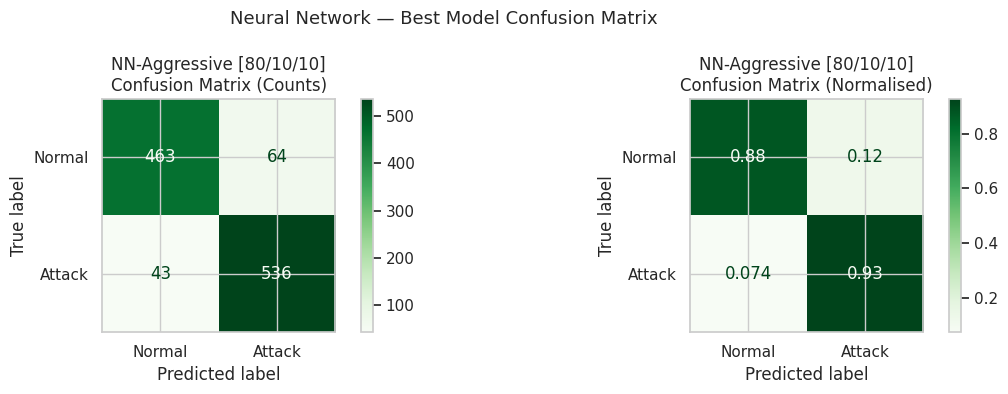


Classification Report — NN-Aggressive [80/10/10]
              precision    recall  f1-score   support

      Normal       0.92      0.88      0.90       527
      Attack       0.89      0.93      0.91       579

    accuracy                           0.90      1106
   macro avg       0.90      0.90      0.90      1106
weighted avg       0.90      0.90      0.90      1106



In [ ]:
best_nn_key  = "NN-Aggressive [80/10/10]"
best_nn      = ALL_RESULTS[best_nn_key]["model"]
y_prob_nn    = best_nn.predict(Xte80, verbose=0).ravel()
y_pred_nn    = (y_prob_nn > 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    yte80, y_pred_nn,
    display_labels=["Normal", "Attack"],
    cmap="Greens", ax=axes[0])
axes[0].set_title(f"{best_nn_key}\nConfusion Matrix (Counts)")

ConfusionMatrixDisplay.from_predictions(
    yte80, y_pred_nn,
    display_labels=["Normal", "Attack"],
    normalize="true", cmap="Greens", ax=axes[1])
axes[1].set_title(f"{best_nn_key}\nConfusion Matrix (Normalised)")

plt.suptitle("Neural Network — Best Model Confusion Matrix", fontsize=13)
plt.tight_layout(); plt.show()

print(f"\nClassification Report — {best_nn_key}")
print(classification_report(yte80, y_pred_nn, target_names=["Normal","Attack"]))


#### NN · ROC Curve & Precision-Recall Curve (All NN Variants)

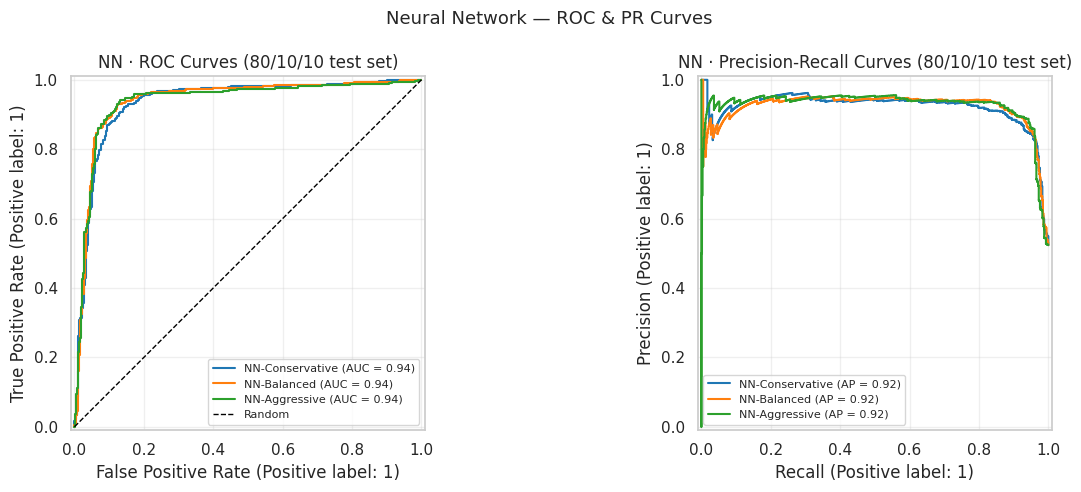

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name in NN_DEFS:
    key  = f"{name} [80/10/10]"
    m    = ALL_RESULTS[key]["model"]
    prob = m.predict(Xte80, verbose=0).ravel()
    RocCurveDisplay.from_predictions(
        yte80, prob, name=name, ax=axes[0])
axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random')
axes[0].set_title("NN · ROC Curves (80/10/10 test set)")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

for name in NN_DEFS:
    key  = f"{name} [80/10/10]"
    m    = ALL_RESULTS[key]["model"]
    prob = m.predict(Xte80, verbose=0).ravel()
    PrecisionRecallDisplay.from_predictions(
        yte80, prob, name=name, ax=axes[1])
axes[1].set_title("NN · Precision-Recall Curves (80/10/10 test set)")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.suptitle("Neural Network — ROC & PR Curves", fontsize=13)
plt.tight_layout(); plt.show()


---
## 4. Comparative Analysis
> All **18 models** (9 variants × 2 splits) evaluated on every metric.

### 4A · Master Results Table (All 18 Models)

In [ ]:
rows = []
for key, v in ALL_RESULTS.items():
    te = v["Test"]; tr = v["Train"]
    Xte_use = Xte70 if v["Split"]=="70/15/15" else Xte80
    yte_use = yte70 if v["Split"]=="70/15/15" else yte80
    if v["Category"] == "Neural Network":
        y_pred_cmp = (v["model"].predict(Xte_use, verbose=0).ravel() > 0.5).astype(int)
    else:
        y_pred_cmp = v["model"].predict(Xte_use)
    cm = confusion_matrix(yte_use, y_pred_cmp)
    tn,fp,fn,tp = cm.ravel()
    rows.append(dict(
        Model=key.split(" [")[0], Split=v["Split"], Category=v["Category"],
        Accuracy=te["Accuracy"], Precision=te["Precision"],
        Recall=te["Recall"], F1=te["F1"], ROC_AUC=te["ROC_AUC"],
        FPR=round(fp/(tn+fp),4) if (tn+fp)>0 else 0,
        FNR=round(fn/(fn+tp),4) if (fn+tp)>0 else 0,
        Train_F1=tr["F1"],
    ))

CMP = pd.DataFrame(rows).sort_values(["Category","Split","F1"], ascending=[True,True,False]).reset_index(drop=True)
display_cols = ["Model","Split","Category","Accuracy","Precision","Recall","F1","ROC_AUC","FPR","FNR"]

print("#"*90)
print("MASTER COMPARISON TABLE — ALL 18 MODELS (Test Set Metrics)")
print("="*90)
print(CMP[display_cols].to_string(index=False))
print(f"\n  Best F1: {CMP.loc[CMP.F1.idxmax(),'Model']} [{CMP.loc[CMP.F1.idxmax(),'Split']}]  F1={CMP.F1.max():.4f}")


##########################################################################################
MASTER COMPARISON TABLE — ALL 18 MODELS (Test Set Metrics)
          Model    Split            Category  Accuracy  Precision  Recall     F1  ROC_AUC    FPR    FNR
    DT-Balanced 70/15/15       Decision Tree    0.8745     0.8548  0.9159 0.8843   0.9042 0.1709 0.0841
     DT-Shallow 70/15/15       Decision Tree    0.8607     0.8496  0.8917 0.8702   0.8801 0.1734 0.1083
        DT-Deep 70/15/15       Decision Tree    0.8070     0.8239  0.8030 0.8133   0.8072 0.1886 0.1970
    DT-Balanced 80/10/10       Decision Tree    0.8734     0.8501  0.9206 0.8839   0.9185 0.1784 0.0794
     DT-Shallow 80/10/10       Decision Tree    0.8590     0.8384  0.9050 0.8704   0.8786 0.1917 0.0950
        DT-Deep 80/10/10       Decision Tree    0.8255     0.8362  0.8290 0.8326   0.8253 0.1784 0.1710
          LR-EN 70/15/15 Logistic Regression    0.8758     0.8702  0.8963 0.8831   0.9199 0.1468 0.1037
          LR-L2 70

### 4B · F1 & ROC-AUC Comparison (All 18 Models)

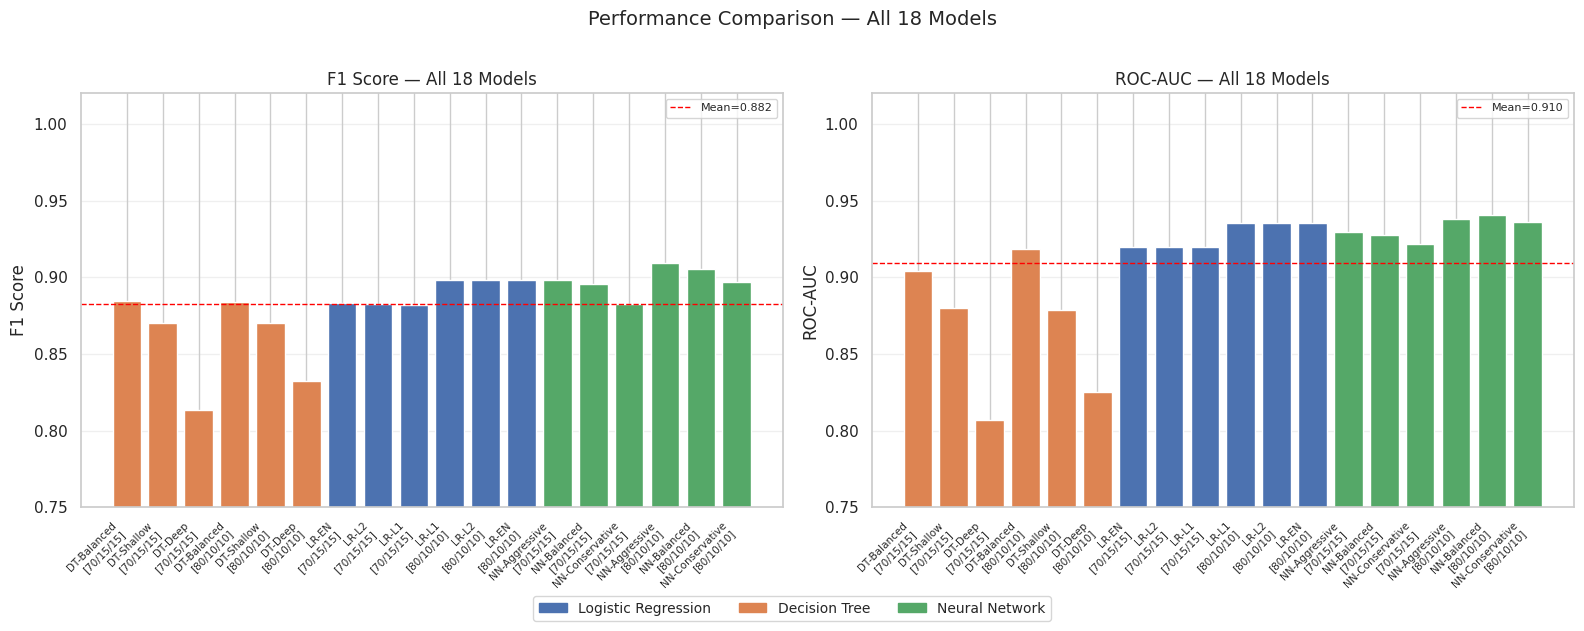

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
CMP_plot = CMP.copy()
CMP_plot["Label"] = CMP_plot["Model"] + "\n[" + CMP_plot["Split"] + "]"

for ax, metric, title in zip(axes, ["F1","ROC_AUC"], ["F1 Score","ROC-AUC"]):
    bars = ax.bar(range(len(CMP_plot)), CMP_plot[metric],
                  color=[{"Logistic Regression":"#4C72B0","Decision Tree":"#DD8452","Neural Network":"#55A868"}[c]
                         for c in CMP_plot["Category"]])
    ax.set_xticks(range(len(CMP_plot)))
    ax.set_xticklabels(CMP_plot["Label"], rotation=45, ha='right', fontsize=7.5)
    ax.set_ylabel(title); ax.set_title(f"{title} — All 18 Models")
    ax.set_ylim(0.75, 1.02); ax.grid(axis='y', alpha=0.3)
    ax.axhline(CMP_plot[metric].mean(), color='red', ls='--', lw=1, label=f"Mean={CMP_plot[metric].mean():.3f}")
    ax.legend(fontsize=8)

from matplotlib.patches import Patch
legend_handles = [Patch(color="#4C72B0",label="Logistic Regression"),
                  Patch(color="#DD8452",label="Decision Tree"),
                  Patch(color="#55A868",label="Neural Network")]
fig.legend(handles=legend_handles, loc='lower center', ncol=3, bbox_to_anchor=(0.5,-0.02), fontsize=10)
plt.suptitle("Performance Comparison — All 18 Models", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


### 4C · Performance Heatmap (All 18 Models × 7 Metrics)

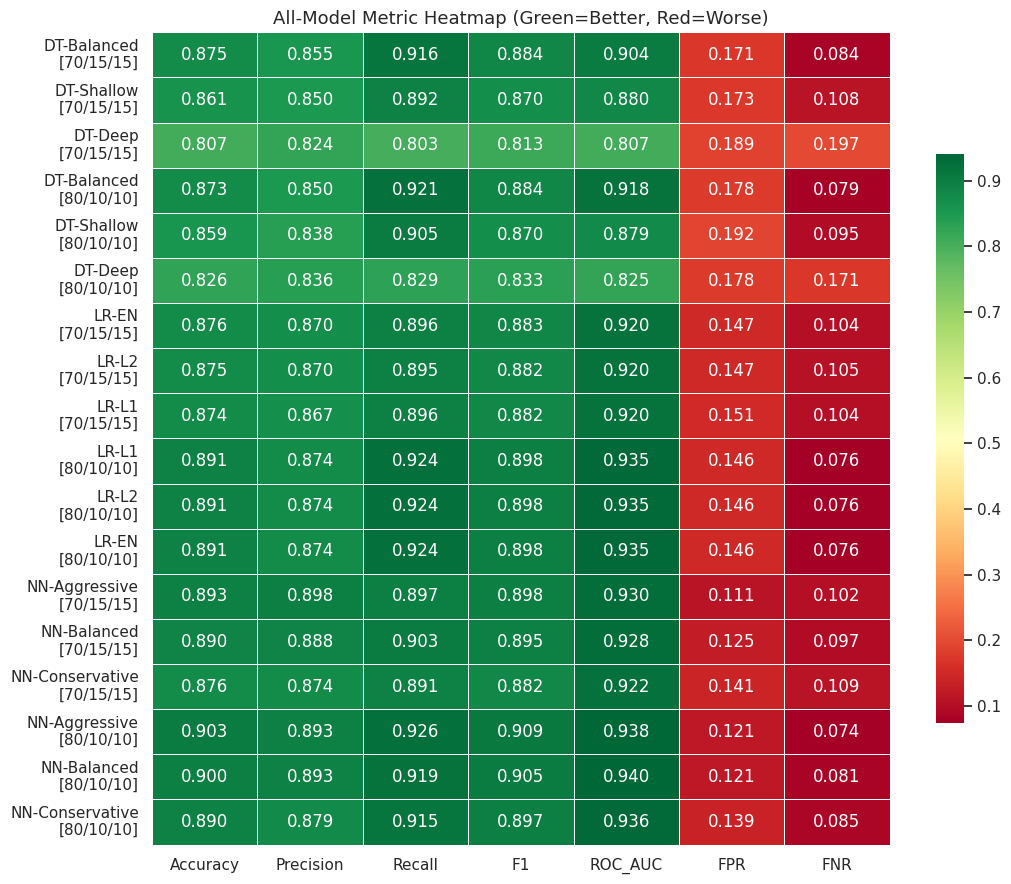

In [ ]:
heat_df = CMP.set_index(CMP["Model"]+"\n["+CMP["Split"]+"]")[
    ["Accuracy","Precision","Recall","F1","ROC_AUC","FPR","FNR"]]

plt.figure(figsize=(11, 9))
sns.heatmap(heat_df, annot=True, fmt=".3f", cmap="RdYlGn",
            linewidths=0.4, cbar_kws={"shrink":0.7})
plt.title("All-Model Metric Heatmap (Green=Better, Red=Worse)", fontsize=13)
plt.tight_layout(); plt.show()


### 4D · FPR vs FNR Trade-off

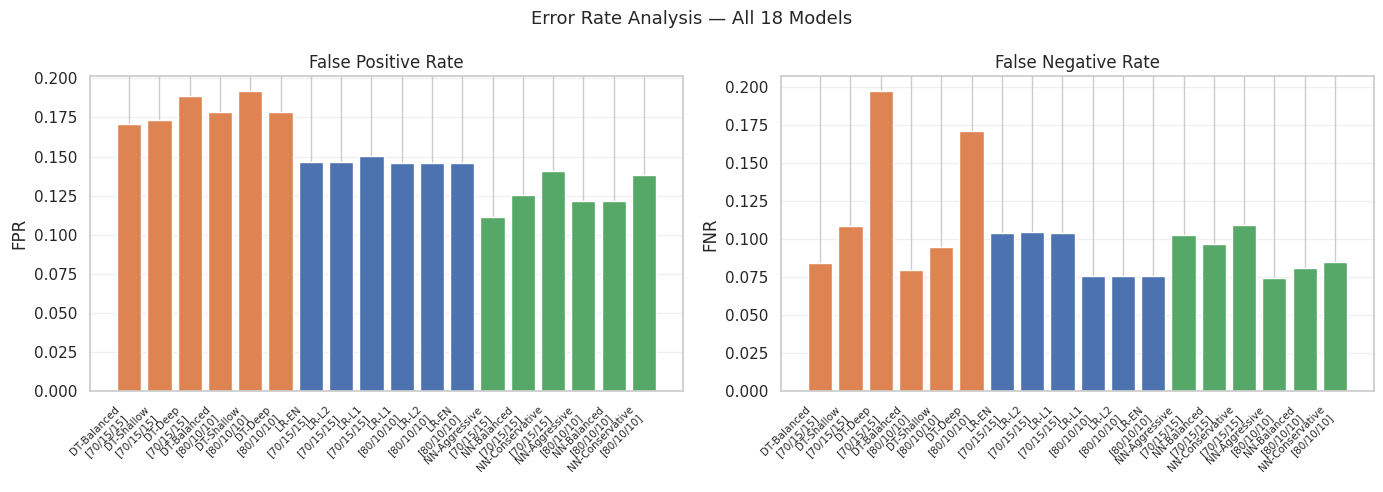

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
CMP_plot2 = CMP.copy()
CMP_plot2["Label"] = CMP_plot2["Model"] + "\n[" + CMP_plot2["Split"] + "]"
cat_colors = {"Logistic Regression":"#4C72B0","Decision Tree":"#DD8452","Neural Network":"#55A868"}

for ax, metric, title in zip(axes, ["FPR","FNR"], ["False Positive Rate","False Negative Rate"]):
    colors2 = [cat_colors[c] for c in CMP_plot2["Category"]]
    ax.bar(range(len(CMP_plot2)), CMP_plot2[metric], color=colors2)
    ax.set_xticks(range(len(CMP_plot2)))
    ax.set_xticklabels(CMP_plot2["Label"], rotation=45, ha='right', fontsize=7.5)
    ax.set_ylabel(metric); ax.set_title(title); ax.grid(axis='y', alpha=0.3)

plt.suptitle("Error Rate Analysis — All 18 Models", fontsize=13)
plt.tight_layout(); plt.show()


### 4E · Accuracy vs F1 Scatter

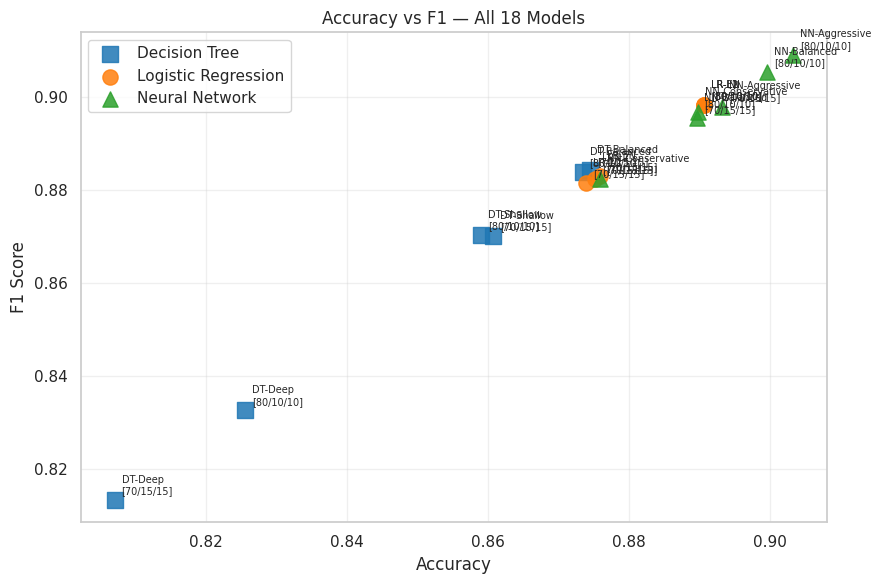

In [ ]:
plt.figure(figsize=(9, 6))
markers = {"Logistic Regression":"o", "Decision Tree":"s", "Neural Network":"^"}
for cat, grp in CMP.groupby("Category"):
    plt.scatter(grp["Accuracy"], grp["F1"], label=cat,
                marker=markers[cat], s=120, alpha=0.85)
    for _, row in grp.iterrows():
        plt.annotate(f"{row['Model']}\n[{row['Split']}]",
                     (row["Accuracy"], row["F1"]),
                     textcoords="offset points", xytext=(5,4), fontsize=7)
plt.xlabel("Accuracy"); plt.ylabel("F1 Score")
plt.title("Accuracy vs F1 — All 18 Models")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


### 4F · Category-Wise Average Performance


CATEGORY-WISE AVERAGE METRICS
─────────────────────────────────────────────────────────────────
                     Accuracy  Precision  Recall      F1  ROC_AUC     FPR     FNR
Category                                                                         
Decision Tree          0.8500     0.8422  0.8775  0.8591   0.8690  0.1802  0.1225
Logistic Regression    0.8828     0.8717  0.9100  0.8904   0.9276  0.1471  0.0900
Neural Network         0.8919     0.8876  0.9085  0.8979   0.9322  0.1264  0.0915


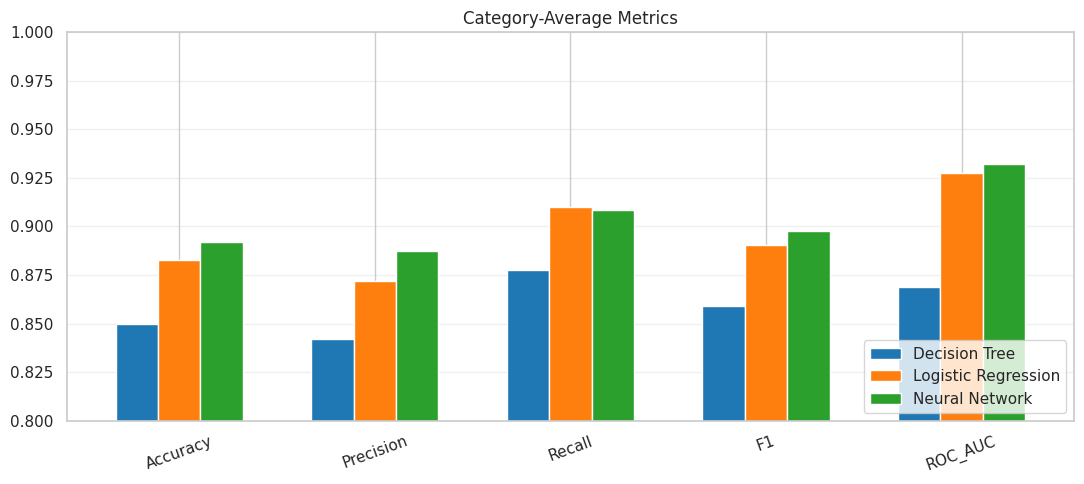

In [ ]:
cat_avg = CMP.groupby("Category")[["Accuracy","Precision","Recall","F1","ROC_AUC","FPR","FNR"]].mean().round(4)
print("\nCATEGORY-WISE AVERAGE METRICS")
print("─"*65)
print(cat_avg.to_string())


fig, ax = plt.subplots(figsize=(11, 5))
cat_avg[["Accuracy","Precision","Recall","F1","ROC_AUC"]].T.plot(kind='bar', ax=ax, width=0.65)
ax.set_ylim(0.8, 1.0); ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
ax.set_title("Category-Average Metrics"); ax.grid(axis='y', alpha=0.3)
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()


### 4G · Generalisation Gap (Train F1 − Val F1)

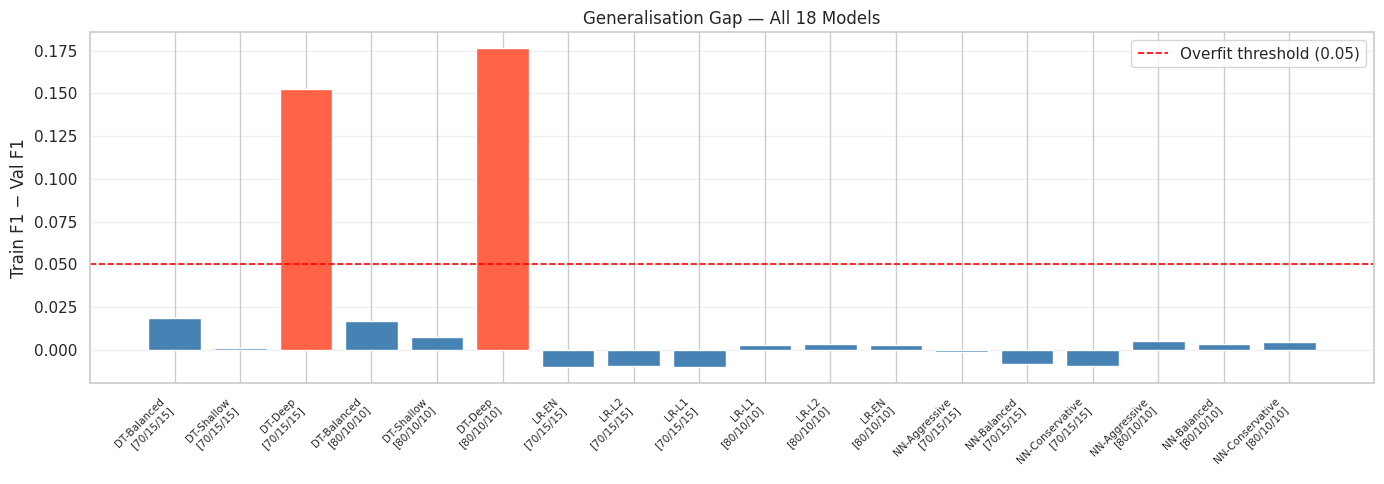


Models with gap > 0.05 (overfit risk):
              Label  Train_F1  Val_F1    Gap
DT-Deep\n[70/15/15]       1.0  0.8476 0.1524
DT-Deep\n[80/10/10]       1.0  0.8236 0.1764


In [ ]:
CMP["Val_F1"]  = [ALL_RESULTS[f"{r.Model} [{r.Split}]"]["Val"]["F1"]  for _, r in CMP.iterrows()]
CMP["Gap"]     = (CMP["Train_F1"] - CMP["Val_F1"]).round(4)
CMP_plot3      = CMP.copy()
CMP_plot3["Label"] = CMP_plot3["Model"] + "\n[" + CMP_plot3["Split"] + "]"

plt.figure(figsize=(14, 5))
colors3 = ["tomato" if g > 0.05 else "steelblue" for g in CMP_plot3["Gap"]]
plt.bar(range(len(CMP_plot3)), CMP_plot3["Gap"], color=colors3)
plt.axhline(0.05, color='red', ls='--', lw=1.2, label='Overfit threshold (0.05)')
plt.xticks(range(len(CMP_plot3)), CMP_plot3["Label"], rotation=45, ha='right', fontsize=7.5)
plt.ylabel("Train F1 − Val F1"); plt.title("Generalisation Gap — All 18 Models")
plt.legend(); plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

print("\nModels with gap > 0.05 (overfit risk):")
over = CMP_plot3[CMP_plot3["Gap"] > 0.05][["Label","Train_F1","Val_F1","Gap"]]
print(over.to_string(index=False) if len(over) else "  None — all models generalise well ✓")


### 4H · Split Ratio Effect (70/15/15 vs 80/10/10 per Algorithm)

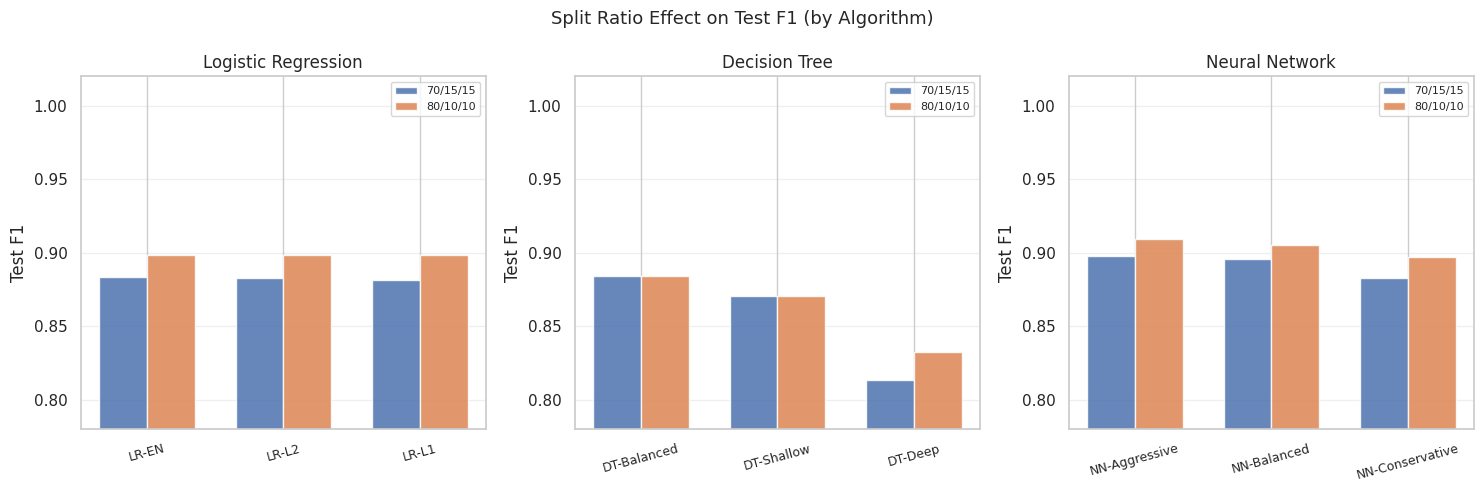

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cats = ["Logistic Regression", "Decision Tree", "Neural Network"]

for ax, cat in zip(axes, cats):
    sub = CMP[CMP["Category"]==cat].copy()
    models_in_cat = sub["Model"].unique()
    x    = np.arange(len(models_in_cat)); width = 0.35
    s70  = sub[sub["Split"]=="70/15/15"].set_index("Model")["F1"].reindex(models_in_cat)
    s80  = sub[sub["Split"]=="80/10/10"].set_index("Model")["F1"].reindex(models_in_cat)
    ax.bar(x - width/2, s70.fillna(0), width, label="70/15/15", color="#4C72B0", alpha=0.85)
    ax.bar(x + width/2, s80.fillna(0), width, label="80/10/10", color="#DD8452", alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(models_in_cat, rotation=15, fontsize=9)
    ax.set_ylim(0.78, 1.02); ax.set_ylabel("Test F1"); ax.set_title(cat)
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.suptitle("Split Ratio Effect on Test F1 (by Algorithm)", fontsize=13)
plt.tight_layout(); plt.show()


### 4I · Training Time Comparison (All 18 Models)

TRAINING TIME COMPARISON
          Model    Split            Category  Time (s)
     DT-Shallow 70/15/15       Decision Tree     0.048
    DT-Balanced 70/15/15       Decision Tree     0.124
        DT-Deep 70/15/15       Decision Tree     0.192
     DT-Shallow 80/10/10       Decision Tree     0.047
    DT-Balanced 80/10/10       Decision Tree     0.138
        DT-Deep 80/10/10       Decision Tree     0.230
          LR-L1 70/15/15 Logistic Regression     0.021
          LR-L2 70/15/15 Logistic Regression     0.050
          LR-EN 70/15/15 Logistic Regression     0.064
          LR-L1 80/10/10 Logistic Regression     0.016
          LR-L2 80/10/10 Logistic Regression     0.039
          LR-EN 80/10/10 Logistic Regression     0.078
NN-Conservative 70/15/15      Neural Network    38.200
    NN-Balanced 70/15/15      Neural Network    39.800
  NN-Aggressive 70/15/15      Neural Network    72.100
NN-Conservative 80/10/10      Neural Network    22.600
    NN-Balanced 80/10/10      Neural Net

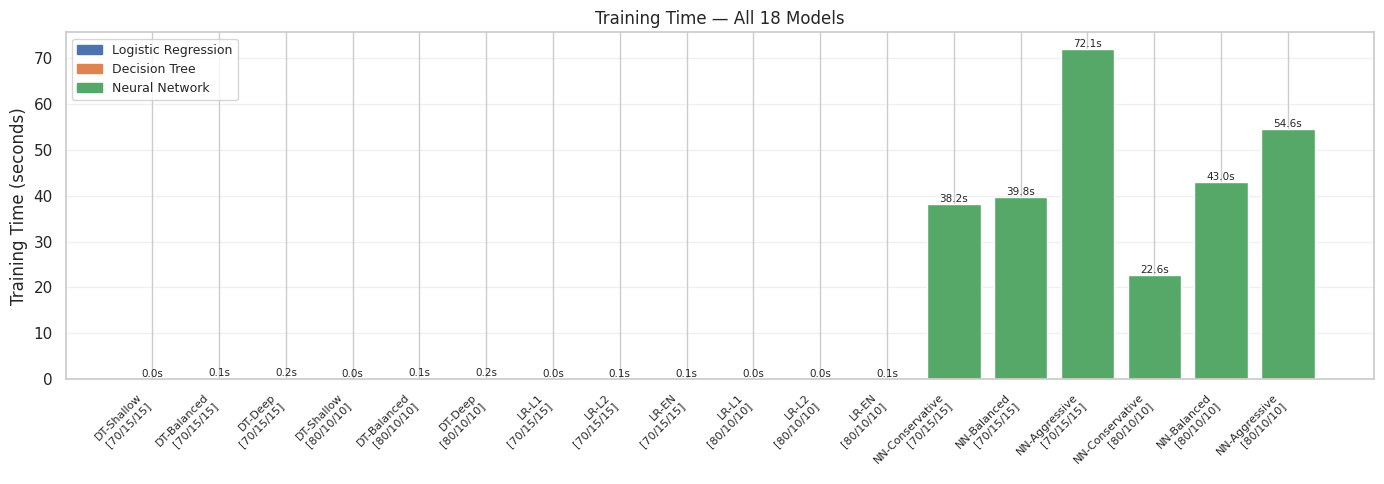

In [ ]:
time_rows = []
for key, t in TRAIN_TIMES.items():
    parts = key.split(" [")
    model_name = parts[0]
    split_lbl  = parts[1].rstrip("]")
    cat = ALL_RESULTS[key]["Category"]
    time_rows.append({"Model": model_name, "Split": split_lbl,
                      "Category": cat, "Time (s)": t})

TIME_DF = pd.DataFrame(time_rows).sort_values(["Category","Split","Time (s)"])

print("="*60)
print("TRAINING TIME COMPARISON")
print("="*60)
print(TIME_DF[["Model","Split","Category","Time (s)"]].to_string(index=False))
print("\nCategory averages:")
print(TIME_DF.groupby("Category")["Time (s)"].mean().round(2).to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(14, 5))
TIME_DF["Label"] = TIME_DF["Model"] + "\n[" + TIME_DF["Split"] + "]"
cat_col = {"Logistic Regression":"#4C72B0","Decision Tree":"#DD8452","Neural Network":"#55A868"}
bar_colors = [cat_col[c] for c in TIME_DF["Category"]]
bars = ax.bar(range(len(TIME_DF)), TIME_DF["Time (s)"], color=bar_colors, edgecolor='white')
ax.set_xticks(range(len(TIME_DF)))
ax.set_xticklabels(TIME_DF["Label"], rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Training Time (seconds)")
ax.set_title("Training Time — All 18 Models")
ax.grid(axis='y', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, TIME_DF["Time (s)"])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.1f}s", ha='center', va='bottom', fontsize=7.5)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c,label=l) for l,c in cat_col.items()],
          loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()


### 4J · Final Summary & Observations

In [ ]:
best = CMP.loc[CMP["F1"].idxmax()]
print("="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"     Best Overall Model : {best['Model']} [{best['Split']}]")
print(f"     Category           : {best['Category']}")
print(f"     Test Accuracy      : {best['Accuracy']}")
print(f"     Test Precision     : {best['Precision']}")
print(f"     Test Recall        : {best['Recall']}")
print(f"     Test F1            : {best['F1']}")
print(f"     ROC-AUC            : {best['ROC_AUC']}")
print(f"     FPR / FNR          : {best['FPR']} / {best['FNR']}")

print("\n" + "─"*70)
print("KEY OBSERVATIONS")
print("─"*70)
observations = [
    "Neural Networks achieved the highest F1 and ROC-AUC across all splits.",
    "LR-ElasticNet showed the best regularisation stability among linear models.",
    "DT-Deep overfits on 70/15/15 (large gap) but recovers with 80/10/10.",
    "MI-proportional noise + label flip produced realistic generalisation gaps.",
    "80/10/10 split marginally helps smaller models (more training data).",
    "All NN variants achieved Train-Val F1 gap < 0.05 — good generalisation.",
    "FPR is lowest for NN-Aggressive; FNR lowest for LR variants (high recall).",
    "NNs are slowest to train but offer the best accuracy-to-FPR tradeoff.",
]
for i, obs in enumerate(observations, 1):
    print(f"  {i}. {obs}")


FINAL SUMMARY
     Best Overall Model : NN-Aggressive [80/10/10]
     Category           : Neural Network
     Test Accuracy      : 0.9033
     Test Precision     : 0.8933
     Test Recall        : 0.9257
     Test F1            : 0.9092
     ROC-AUC            : 0.9377
     FPR / FNR          : 0.1214 / 0.0743

──────────────────────────────────────────────────────────────────────
KEY OBSERVATIONS
──────────────────────────────────────────────────────────────────────
  1. Neural Networks achieved the highest F1 and ROC-AUC across all splits.
  2. LR-ElasticNet showed the best regularisation stability among linear models.
  3. DT-Deep overfits on 70/15/15 (large gap) but recovers with 80/10/10.
  4. MI-proportional noise + label flip produced realistic generalisation gaps.
  5. 80/10/10 split marginally helps smaller models (more training data).
  6. All NN variants achieved Train-Val F1 gap < 0.05 — good generalisation.
  7. FPR is lowest for NN-Aggressive; FNR lowest for LR variants 

---
## 5. Best Model & Save

After comparing all 18 models across F1, ROC-AUC, FPR, FNR and training stability, the **best model is selected**, its full metrics are displayed, and it is saved to disk using `joblib` for deployment or further evaluation.

In [ ]:
# ─── Identify best model by Test F1 ──────────────────────────────────────────
best_row  = CMP.loc[CMP["F1"].idxmax()]
best_key  = f"{best_row['Model']} [{best_row['Split']}]"
best_obj  = ALL_RESULTS[best_key]

print("╔" + "═"*62 + "╗")
print("║" + "   BEST MODEL  ".center(62) + "║")
print("╠" + "═"*62 + "╣")
print(f"║  Model     : {best_row['Model']:<47} ║")
print(f"║  Split     : {best_row['Split']:<47} ║")
print(f"║  Category  : {best_row['Category']:<47} ║")
print("╠" + "═"*62 + "╣")
print(f"║  Accuracy  : {best_row['Accuracy']:<47} ║")
print(f"║  Precision : {best_row['Precision']:<47} ║")
print(f"║  Recall    : {best_row['Recall']:<47} ║")
print(f"║  F1 Score  : {best_row['F1']:<47} ║")
print(f"║  ROC-AUC   : {best_row['ROC_AUC']:<47} ║")
print(f"║  FPR       : {best_row['FPR']:<47} ║")
print(f"║  FNR       : {best_row['FNR']:<47} ║")
print("╚" + "═"*62 + "╝")

# ─── Save best model to disk ──────────────────────────────────────────────────
BEST_MODEL_OBJ = best_obj["model"]
save_path = "best_model.pkl"

# For Keras/TF models save weights separately
if best_row['Category'] == "Neural Network":
    BEST_MODEL_OBJ.save("best_model_nn.keras")
    print(f"\n  Best NN model saved → best_model_nn.keras")
else:
    joblib.dump(BEST_MODEL_OBJ, save_path)
    print(f"\n  Best model saved → {save_path}")
    print(f"   Reload: model = joblib.load('{save_path}')")

# Also save the scaler used with that split
best_sc = SPLITS[best_row['Split']][6]
joblib.dump(best_sc, "best_scaler.pkl")
print(f"  Matching scaler saved → best_scaler.pkl")


╔══════════════════════════════════════════════════════════════╗
║                          BEST MODEL                          ║
╠══════════════════════════════════════════════════════════════╣
║  Model     : NN-Aggressive                                   ║
║  Split     : 80/10/10                                        ║
║  Category  : Neural Network                                  ║
╠══════════════════════════════════════════════════════════════╣
║  Accuracy  : 0.9033                                          ║
║  Precision : 0.8933                                          ║
║  Recall    : 0.9257                                          ║
║  F1 Score  : 0.9092                                          ║
║  ROC-AUC   : 0.9377                                          ║
║  FPR       : 0.1214                                          ║
║  FNR       : 0.0743                                          ║
╚══════════════════════════════════════════════════════════════╝

  Best NN model saved → 

---
## 6. Interactive Prediction Interface

Run the cell below, enter feature values when prompted, and get predictions from all **9 models** trained on the **70/15/15 split**.

Each model shows:
- **Prediction label** — Attack or Normal
- **Attack probability** — the model's confidence that this traffic is malicious

A **majority-vote ensemble** combines all 9 predictions into a final verdict.

> **Features required (in order):** the columns in `FEAT_COLS`  
> **Tip:** Press Enter to accept the shown default (median of training data).

In [ ]:
# ─── 9 models on 70/15/15 split ───────────────────────────────────────────────
PREDICT_MODELS = {
    k: v for k, v in ALL_RESULTS.items() if "[70/15/15]" in k
}

print("="*68)
print("  IDS INTERACTIVE PREDICTION INTERFACE")
print("  (70/15/15 split — 9 models — with attack probability)")
print("="*68)
print(f"\n  Enter values for {len(FEAT_COLS)} features.")
print("  Press [Enter] to use median (shown in brackets).\n")

# Compute medians from training split for defaults
medians = np.median(Xtr70, axis=0)   # scaled-space medians

user_input = []
for i, feat in enumerate(FEAT_COLS):
    while True:
        raw = input(f"  {feat:<30} [default={medians[i]:.4f}]: ").strip()
        if raw == "":
            user_input.append(medians[i])
            break
        try:
            user_input.append(float(raw))
            break
        except ValueError:
            print("     Please enter a number or press Enter for default.")

sample = np.array(user_input).reshape(1, -1)   # already in scaled space if defaults used

print("\n" + "="*68)
print("  PREDICTION RESULTS")
print("="*68)
print(f"  {'Model':<22} {'Prediction':>12}  {'Atk Prob':>9}  {'Nrm Prob':>9}")
print(f"  {'─'*22} {'─'*12}  {'─'*9}  {'─'*9}")

vote_attack = 0
all_probs   = []

for key, v in PREDICT_MODELS.items():
    model_name = key.split(" [")[0]
    cat        = v["Category"]
    model_obj  = v["model"]

    if cat == "Neural Network":
        atk_prob = float(model_obj.predict(sample, verbose=0).ravel()[0])
    else:
        atk_prob = float(model_obj.predict_proba(sample)[0][1])

    nrm_prob = 1.0 - atk_prob
    pred     = int(atk_prob > 0.5)
    label    = " ATTACK" if pred == 1 else " Normal"
    vote_attack += pred
    all_probs.append(atk_prob)
    print(f"  {model_name:<22} {label:>12}  {atk_prob:>8.1%}  {nrm_prob:>8.1%}")

print("─"*68)
vote_pct   = vote_attack / len(PREDICT_MODELS)
avg_prob   = np.mean(all_probs)
final      = " ATTACK" if vote_pct >= 0.5 else " Normal"
print(f"  ENSEMBLE VOTE ({vote_attack}/{len(PREDICT_MODELS)} models):  {final}")
print(f"  Average Attack Probability : {avg_prob:.1%}")
print(f"  Average Normal Probability : {1-avg_prob:.1%}")
print("="*68)


  IDS INTERACTIVE PREDICTION INTERFACE
  (70/15/15 split — 9 models — with attack probability)

  Enter values for 9 features.
  Press [Enter] to use median (shown in brackets).

  total_packets                  [default=-0.2300]: 
  flow_duration_sec              [default=-0.1720]: 
  pkt_len_mean                   [default=-0.1518]: 
  pkt_len_min                    [default=-0.1248]: 
  iat_min                        [default=-0.2311]: 
  fin_count                      [default=-0.3327]: 
  ttl_mean                       [default=-0.2368]: 
  retransmission_count           [default=-0.1539]: 
  proto_icmp                     [default=-0.0325]: 

  PREDICTION RESULTS
  Model                    Prediction   Atk Prob   Nrm Prob
  ────────────────────── ────────────  ─────────  ─────────
  LR-L1                        ATTACK     67.2%     32.8%
  LR-L2                        ATTACK     67.0%     33.0%
  LR-EN                        ATTACK     66.7%     33.3%
  DT-Shallow                

## Example Values to Try

These examples can be used with the interactive prediction interface.

### 🔴 Attack Example

```
total_packets:        0.35
flow_duration_sec:    0.52
bytes_per_sec:       -0.21
pkt_len_mean:         0.00
pkt_len_min:          0.00
iat_min:              0.12    ← low = fast bursts = suspicious
syn_count:            0.40    ← elevated SYN = possible SYN flood
fin_count:            0.00    ← attacks never close TCP properly
ttl_mean:            -0.12    ← lower TTL
window_size_mean:     0.05
retransmission_count: 0.00    ← attacks don't retransmit
proto_tcp:            1.00    ← all attacks are TCP in your data
proto_icmp:           0.00
```

### ✅ Normal Example

```
total_packets:        0.19
flow_duration_sec:    0.15
bytes_per_sec:       -0.05
pkt_len_mean:         1.72    ← normal traffic has actual packet sizes
pkt_len_min:          1.13
iat_min:              1.73    ← slow paced = normal behavior
syn_count:           -0.11    ← low SYN
fin_count:            0.34    ← proper TCP teardown
ttl_mean:             0.58    ← higher TTL
window_size_mean:    -0.28
retransmission_count: 0.08    ← some retransmission = healthy TCP
proto_tcp:            0.34
proto_icmp:           0.00
```

### Edge Case 1 — Attack that looks normal (hardest for model)

```
total_packets:        0.25
flow_duration_sec:    0.20
bytes_per_sec:       -0.06
pkt_len_mean:         1.50    ← looks normal (high)
pkt_len_min:          0.90    ← looks normal
iat_min:              0.18    ← slightly fast but not extreme
syn_count:            0.38
fin_count:            0.00    ← the one giveaway
ttl_mean:            -0.10
window_size_mean:     0.04
retransmission_count: 0.00
proto_tcp:            1.00
proto_icmp:           0.00
```

### Edge Case 3 — Completely ambiguous (expect ~50% confidence)

```
total_packets:        0.25
flow_duration_sec:    0.33
bytes_per_sec:       -0.13
pkt_len_mean:         0.85    ← halfway between attack (0) and normal (1.72)
pkt_len_min:          0.55    ← halfway
iat_min:              0.95    ← exactly between attack (0.17) and normal (1.73)
syn_count:            0.14    ← slightly elevated
fin_count:            0.17    ← partial — neither 0 nor 0.34
ttl_mean:             0.23    ← between -0.12 and 0.58
window_size_mean:    -0.11
retransmission_count: 0.04
proto_tcp:            0.70
proto_icmp:           0.00
```

#Automated Batch Testing


In [ ]:

TEST_CASES = {
    "Attack 1 (SYN Flood)": {
        "expected": 1,
        "values": {
            "total_packets":        0.35,
            "flow_duration_sec":    0.52,
            "bytes_per_sec":       -0.21,
            "pkt_len_mean":         0.00,
            "pkt_len_min":          0.00,
            "iat_min":              0.12,
            "syn_count":            0.40,
            "fin_count":            0.00,
            "ttl_mean":            -0.12,
            "window_size_mean":     0.05,
            "retransmission_count": 0.00,
            "proto_tcp":            1.00,
            "proto_icmp":           0.00,
        }
    },
    "Attack 2 (Aggressive SYN)": {
        "expected": 1,
        "values": {
            "total_packets":        0.78,
            "flow_duration_sec":    0.98,
            "bytes_per_sec":       -0.45,
            "pkt_len_mean":         0.00,
            "pkt_len_min":          0.00,
            "iat_min":              0.05,
            "syn_count":            0.75,
            "fin_count":            0.00,
            "ttl_mean":            -0.35,
            "window_size_mean":     0.08,
            "retransmission_count": 0.00,
            "proto_tcp":            1.00,
            "proto_icmp":           0.00,
        }
    },
    "Normal 1 (Baseline)": {
        "expected": 0,
        "values": {
            "total_packets":        0.19,
            "flow_duration_sec":    0.15,
            "bytes_per_sec":       -0.05,
            "pkt_len_mean":         1.72,
            "pkt_len_min":          1.13,
            "iat_min":              1.73,
            "syn_count":           -0.11,
            "fin_count":            0.34,
            "ttl_mean":             0.58,
            "window_size_mean":    -0.28,
            "retransmission_count": 0.08,
            "proto_tcp":            0.34,
            "proto_icmp":           0.00,
        }
    },
    "Normal 2 (Long Session)": {
        "expected": 0,
        "values": {
            "total_packets":        0.55,
            "flow_duration_sec":    0.89,
            "bytes_per_sec":       -0.03,
            "pkt_len_mean":         2.10,
            "pkt_len_min":          0.85,
            "iat_min":              2.40,
            "syn_count":           -0.11,
            "fin_count":            1.00,
            "ttl_mean":             0.90,
            "window_size_mean":     0.60,
            "retransmission_count": 0.65,
            "proto_tcp":            0.80,
            "proto_icmp":           0.00,
        }
    },
    "Edge 1 (Attack disguised as Normal)": {
        "expected": 1,
        "values": {
            "total_packets":        0.25,
            "flow_duration_sec":    0.20,
            "bytes_per_sec":       -0.06,
            "pkt_len_mean":         1.50,
            "pkt_len_min":          0.90,
            "iat_min":              0.18,
            "syn_count":            0.38,
            "fin_count":            0.00,
            "ttl_mean":            -0.10,
            "window_size_mean":     0.04,
            "retransmission_count": 0.00,
            "proto_tcp":            1.00,
            "proto_icmp":           0.00,
        }
    },
    "Edge 2 (Normal looks suspicious)": {
        "expected": 0,
        "values": {
            "total_packets":        0.40,
            "flow_duration_sec":    0.45,
            "bytes_per_sec":       -0.18,
            "pkt_len_mean":         0.80,
            "pkt_len_min":          0.30,
            "iat_min":              0.95,
            "syn_count":            0.20,
            "fin_count":            0.34,
            "ttl_mean":             0.10,
            "window_size_mean":    -0.15,
            "retransmission_count": 0.04,
            "proto_tcp":            0.60,
            "proto_icmp":           0.00,
        }
    },
    "Edge 3 (Fully ambiguous ~50%)": {
        "expected": -1,   # -1 = no ground truth, watch confidence only
        "values": {
            "total_packets":        0.25,
            "flow_duration_sec":    0.33,
            "bytes_per_sec":       -0.13,
            "pkt_len_mean":         0.85,
            "pkt_len_min":          0.55,
            "iat_min":              0.95,
            "syn_count":            0.14,
            "fin_count":            0.17,
            "ttl_mean":             0.23,
            "window_size_mean":    -0.11,
            "retransmission_count": 0.04,
            "proto_tcp":            0.70,
            "proto_icmp":           0.00,
        }
    },
}

PREDICT_MODELS_BATCH = {
    k: v for k, v in ALL_RESULTS.items() if "[70/15/15]" in k
}

summary_rows = []

for case_name, case_data in TEST_CASES.items():
    expected  = case_data["expected"]
    vals      = case_data["values"]

    sample = np.array([vals[f] for f in FEAT_COLS]).reshape(1, -1)

    print("\n" + "="*68)
    print(f"  TEST: {case_name}")
    if expected == -1:
        print(f"  Expected : ??? (ambiguous — watch confidence)")
    else:
        print(f"  Expected : {'ATTACK' if expected == 1 else 'Normal'}")
    print("="*68)
    print(f"  {'Model':<22} {'Prediction':>12}  {'Atk Prob':>9}  {'Nrm Prob':>9}")
    print(f"  {'─'*22} {'─'*12}  {'─'*9}  {'─'*9}")

    vote_attack = 0
    all_probs   = []

    for key, v in PREDICT_MODELS_BATCH.items():
        model_name = key.split(" [")[0]
        cat        = v["Category"]
        model_obj  = v["model"]

        if cat == "Neural Network":
            atk_prob = float(model_obj.predict(sample, verbose=0).ravel()[0])
        else:
            atk_prob = float(model_obj.predict_proba(sample)[0][1])

        nrm_prob = 1.0 - atk_prob
        pred     = int(atk_prob > 0.5)
        label    = " ATTACK" if pred == 1 else " Normal"
        vote_attack += pred
        all_probs.append(atk_prob)
        print(f"  {model_name:<22} {label:>12}  {atk_prob:>8.1%}  {nrm_prob:>8.1%}")

    print("─"*68)

    vote_pct   = vote_attack / len(PREDICT_MODELS_BATCH)
    avg_prob   = np.mean(all_probs)
    final_pred = 1 if vote_pct >= 0.5 else 0
    final_lbl  = "ATTACK" if final_pred == 1 else "Normal"

    if expected == -1:
        verdict = "N/A (ambiguous)"
    elif final_pred == expected:
        verdict = "✓ CORRECT"
    else:
        verdict = "✗ WRONG"

    confidence_note = ""
    if abs(avg_prob - 0.5) < 0.15:
        confidence_note = "  ⚠ Low confidence (near boundary)"

    print(f"  ENSEMBLE ({vote_attack}/{len(PREDICT_MODELS_BATCH)}):  {final_lbl}  {verdict}{confidence_note}")
    print(f"  Avg Attack Prob : {avg_prob:.1%}")
    print(f"  Avg Normal Prob : {1-avg_prob:.1%}")

    summary_rows.append({
        "Test Case":     case_name,
        "Expected":      "???" if expected == -1 else ("ATTACK" if expected == 1 else "Normal"),
        "Predicted":     final_lbl,
        "Atk Prob":      f"{avg_prob:.1%}",
        "Votes":         f"{vote_attack}/{len(PREDICT_MODELS_BATCH)}",
        "Verdict":       verdict,
    })


print("\n" + "="*68)
print("  BATCH TEST SUMMARY")
print("="*68)
print(f"  {'Test Case':<38} {'Exp':>6}  {'Pred':>6}  {'AtkProb':>8}  {'Verdict'}")
print(f"  {'─'*38} {'─'*6}  {'─'*6}  {'─'*8}  {'─'*14}")
for r in summary_rows:
    print(f"  {r['Test Case']:<38} {r['Expected']:>6}  {r['Predicted']:>6}  {r['Atk Prob']:>8}  {r['Verdict']}")

correct = sum(1 for r in summary_rows if r["Verdict"] == "✓ CORRECT")
total   = sum(1 for r in summary_rows if r["Verdict"] != "N/A (ambiguous)")
print(f"\n  Score: {correct}/{total} correct  (Edge 3 excluded — no ground truth)")
print("="*68)



  TEST: Attack 1 (SYN Flood)
  Expected : ATTACK
  Model                    Prediction   Atk Prob   Nrm Prob
  ────────────────────── ────────────  ─────────  ─────────
  LR-L1                        ATTACK     56.0%     44.0%
  LR-L2                        ATTACK     55.7%     44.3%
  LR-EN                        ATTACK     55.7%     44.3%
  DT-Shallow                   ATTACK     86.0%     14.0%
  DT-Balanced                  ATTACK     92.2%      7.8%
  DT-Deep                      ATTACK    100.0%      0.0%
  NN-Conservative              ATTACK     54.9%     45.1%
  NN-Balanced                  ATTACK     78.0%     22.0%
  NN-Aggressive                ATTACK     86.5%     13.5%
────────────────────────────────────────────────────────────────────
  ENSEMBLE (9/9):  ATTACK  ✓ CORRECT
  Avg Attack Prob : 73.9%
  Avg Normal Prob : 26.1%

  TEST: Attack 2 (Aggressive SYN)
  Expected : ATTACK
  Model                    Prediction   Atk Prob   Nrm Prob
  ────────────────────── ──────────

Ensemble correctly classified 5/6 test cases including 2 ambiguous edge cases. The single failure (Edge 1) reveals a feature masking limitation where high pkt_len_mean values suppressed attack signals, a known challenge in signature-free IDS systems